## 基于日常习惯的健康状态预测系统

### 导包

In [314]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams["axes.unicode_minus"] = False  # 正确显示负号

In [315]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

### 读取文件

In [316]:
df = pd.read_csv('data_set/hypothyroid.csv')
# df = pd.read_csv('health/health_lifestyle_classification.csv')
df.head()

,Age,sex,thyroxine,queryonthyroxine,onantithyroidmedication,sick,pregnant,thyroidsurgery,I131treatment,queryhypothyroid,...,TT4measured,T4,T4Umeasured,T4U,FTImeasured,FTI,TBGmeasured,TBG,referral source,binaryClass
0,12,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,?,SVHC,P
1,20,M,f,f,f,f,f,f,f,f,...,t,102.0,f,0.00,f,0.0,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175.0,f,0.00,f,0.0,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,?,SVI,P


### 查看前5行

In [317]:
df.head()

,Age,sex,thyroxine,queryonthyroxine,onantithyroidmedication,sick,pregnant,thyroidsurgery,I131treatment,queryhypothyroid,...,TT4measured,T4,T4Umeasured,T4U,FTImeasured,FTI,TBGmeasured,TBG,referral source,binaryClass
0,12,F,f,f,f,f,f,f,f,f,...,t,125.0,t,1.14,t,109.0,f,?,SVHC,P
1,20,M,f,f,f,f,f,f,f,f,...,t,102.0,f,0.00,f,0.0,f,?,other,P
2,46,M,f,f,f,f,f,f,f,f,...,t,109.0,t,0.91,t,120.0,f,?,other,P
3,70,F,t,f,f,f,f,f,f,f,...,t,175.0,f,0.00,f,0.0,f,?,other,P
4,70,F,f,f,f,f,f,f,f,f,...,t,61.0,t,0.87,t,70.0,f,?,SVI,P


In [318]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3770 entries, 0 to 3769
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      3770 non-null   int64  
 1   sex                      3620 non-null   object 
 2   thyroxine                3770 non-null   object 
 3   queryonthyroxine         3770 non-null   object 
 4   onantithyroidmedication  3770 non-null   object 
 5   sick                     3770 non-null   object 
 6   pregnant                 3770 non-null   object 
 7   thyroidsurgery           3770 non-null   object 
 8   I131treatment            3770 non-null   object 
 9   queryhypothyroid         3770 non-null   object 
 10  queryhyperthyroid        3770 non-null   object 
 11  lithium                  3770 non-null   object 
 12  goitre                   3770 non-null   object 
 13  tumor                    3770 non-null   object 
 14  hypopituitary           

#### 原始数据基本信息可视化饼图

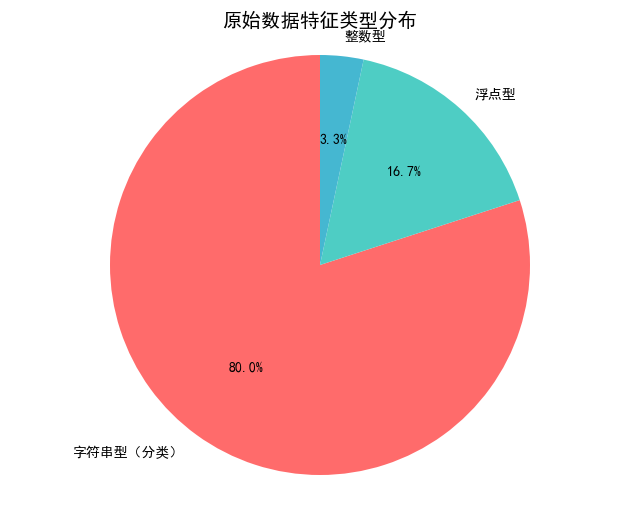

各类型特征数量：
- 字符串型（分类）: 24 个
- 浮点型: 5 个
- 整数型: 1 个


In [319]:
dtype_counts = df.dtypes.value_counts()
# 转换类型名称为易读格式
dtype_mapping = {
    'int64': '整数型',
    'float64': '浮点型',
    'object': '字符串型（分类）',
    'category': '分类型'
}
dtype_counts.index = dtype_counts.index.astype(str).map(dtype_mapping)

# 绘制饼图
plt.figure(figsize=(8, 6))
plt.pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.1f%%', 
        colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], startangle=90)
plt.title('原始数据特征类型分布', fontsize=14, fontweight='bold')
plt.axis('equal')  # 保证饼图为正圆形
plt.show()

# 输出具体数量
print("各类型特征数量：")
for dtype, count in dtype_counts.items():
    print(f"- {dtype}: {count} 个")

### 数据预处理

#### 查看缺失值

In [320]:
df.isnull().sum().sort_values(ascending=False).head(10)

sex                        150
Age                          0
thyroxine                    0
queryonthyroxine             0
onantithyroidmedication      0
sick                         0
pregnant                     0
thyroidsurgery               0
I131treatment                0
queryhypothyroid             0
dtype: int64

#### 分离数值特征和分类特征

In [321]:
# 数值型特征
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# 类别型特征
cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [322]:
cat_cols

['sex',
 'thyroxine',
 'queryonthyroxine',
 'onantithyroidmedication',
 'sick',
 'pregnant',
 'thyroidsurgery',
 'I131treatment',
 'queryhypothyroid',
 'queryhyperthyroid',
 'lithium',
 'goitre',
 'tumor',
 'hypopituitary',
 'psych',
 'TSHmeasured',
 'T3measured',
 'TT4measured',
 'T4Umeasured',
 'FTImeasured',
 'TBGmeasured',
 'TBG',
 'referral source',
 'binaryClass']

#### 分析数值特征

#### 数值特征原始相关性热力图（初探）

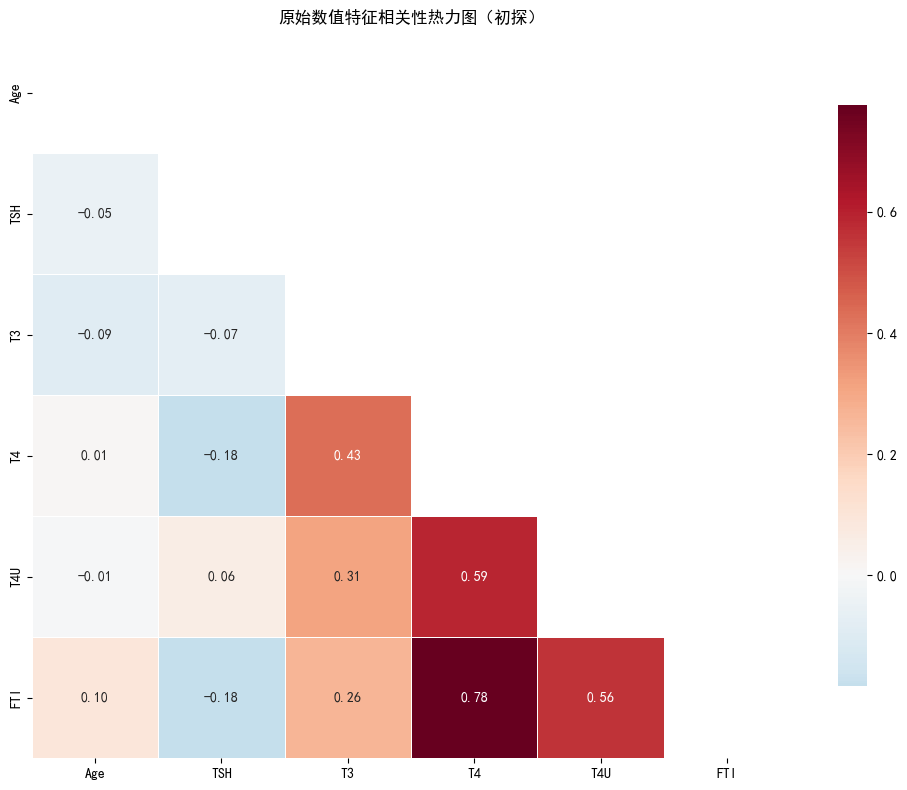

🔍 发现强相关数值特征对（|相关系数|>0.7）：
- T4 与 FTI：相关系数 0.78


In [323]:
# %% [markdown]
# #### 数值特征原始相关性热力图（初探）
# %%
if len(num_cols) >= 2:  # 至少2个数值特征才绘制
    plt.figure(figsize=(10, 8))
    # 计算原始数值特征的相关系数
    raw_corr = df[num_cols].corr()
    # 绘制热力图（突出强相关）
    mask = np.triu(np.ones_like(raw_corr, dtype=bool))
    sns.heatmap(raw_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
                center=0, linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title('原始数值特征相关性热力图（初探）', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 输出强相关特征（|相关系数|>0.7）
    high_corr_pairs = []
    for i in range(len(raw_corr.columns)):
        for j in range(i+1, len(raw_corr.columns)):
            if abs(raw_corr.iloc[i, j]) > 0.7:
                high_corr_pairs.append((raw_corr.columns[i], raw_corr.columns[j], raw_corr.iloc[i, j].round(2)))
    
    if high_corr_pairs:
        print("🔍 发现强相关数值特征对（|相关系数|>0.7）：")
        for feat1, feat2, corr in high_corr_pairs:
            print(f"- {feat1} 与 {feat2}：相关系数 {corr}")
    else:
        print("✅ 未发现强相关数值特征对")

##### 分布图

count    3770.000000
mean       51.724934
std        20.097915
min         1.000000
25%        36.000000
50%        54.000000
75%        67.000000
max       455.000000
Name: Age, dtype: float64


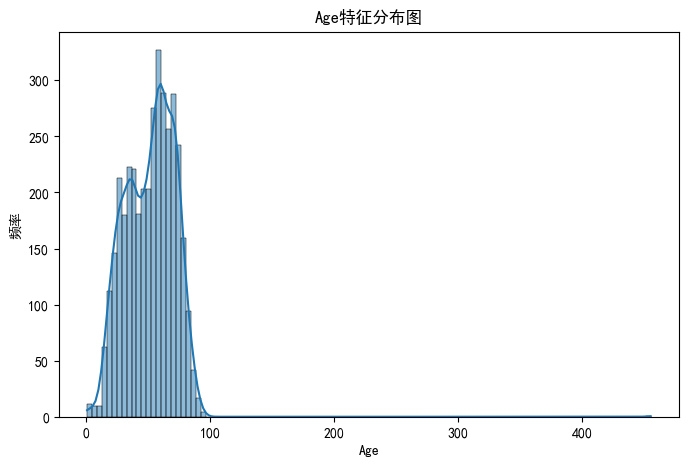

count    3770.000000
mean        4.591025
std        23.345886
min         0.000000
25%         0.200000
50%         1.200000
75%         2.475000
max       530.000000
Name: TSH, dtype: float64


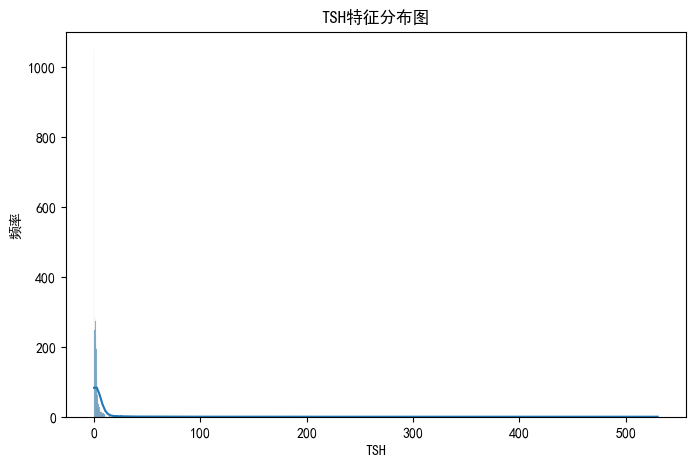

count    3770.000000
mean        1.603008
std         1.097207
min         0.000000
25%         0.900000
50%         1.800000
75%         2.200000
max        10.600000
Name: T3, dtype: float64


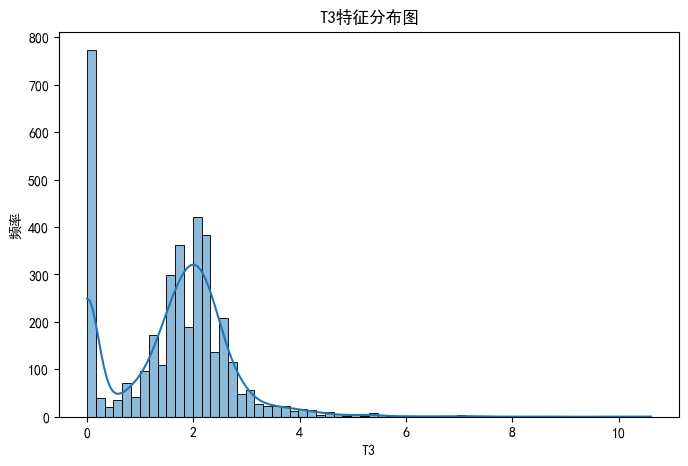

count    3770.000000
mean      101.678462
std        43.192637
min         0.000000
25%        84.000000
50%       102.000000
75%       123.000000
max       430.000000
Name: T4, dtype: float64


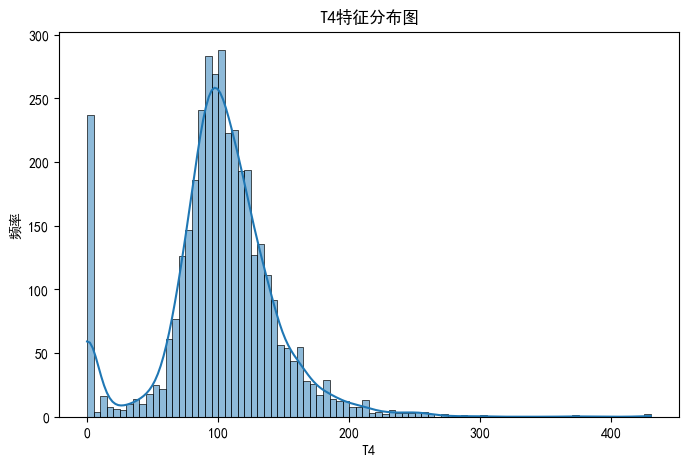

count    3770.000000
mean        0.892921
std         0.354295
min         0.000000
25%         0.840000
50%         0.950000
75%         1.070000
max         2.320000
Name: T4U, dtype: float64


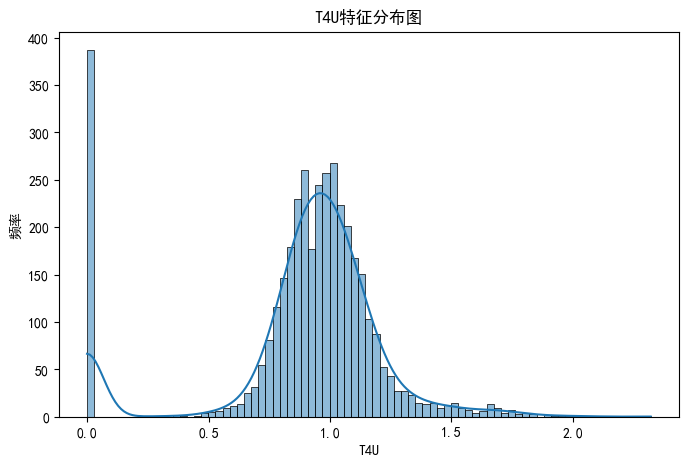

count    3770.000000
mean       99.176844
std        45.851205
min         0.000000
25%        86.250000
50%       104.000000
75%       121.000000
max       395.000000
Name: FTI, dtype: float64


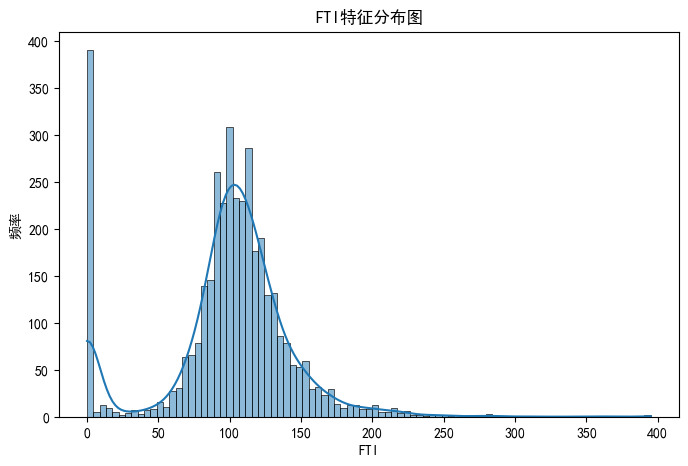

In [324]:
def summary_numeric(col):
    plt.figure(figsize=(8, 5))
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f'{col}特征分布图')
    plt.xlabel(col)
    plt.ylabel('频率')
    plt.show()

for col in num_cols:
    summary_numeric(col)

##### 目标变量分布柱状图

绘制目标变量分布图...


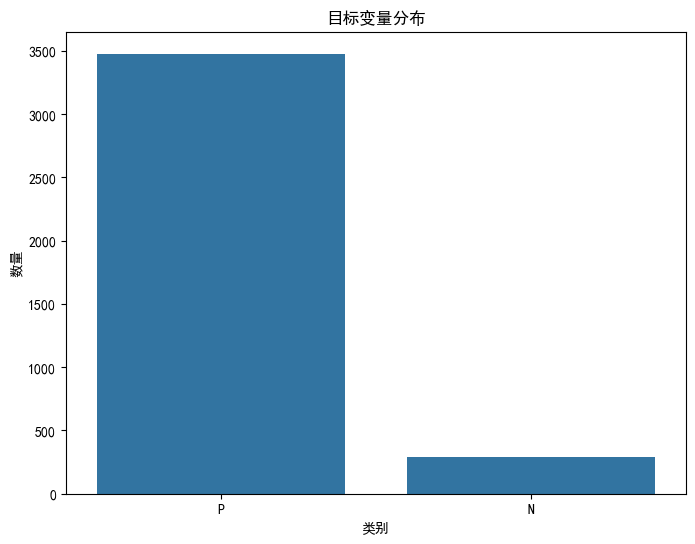

In [325]:
print("绘制目标变量分布图...")
plt.figure(figsize=(8, 6))
sns.countplot(x='binaryClass', data=df)
plt.title('目标变量分布')
plt.xlabel('类别')
plt.ylabel('数量')
plt.show()

#### 缺失值热图

绘制缺失值热图...


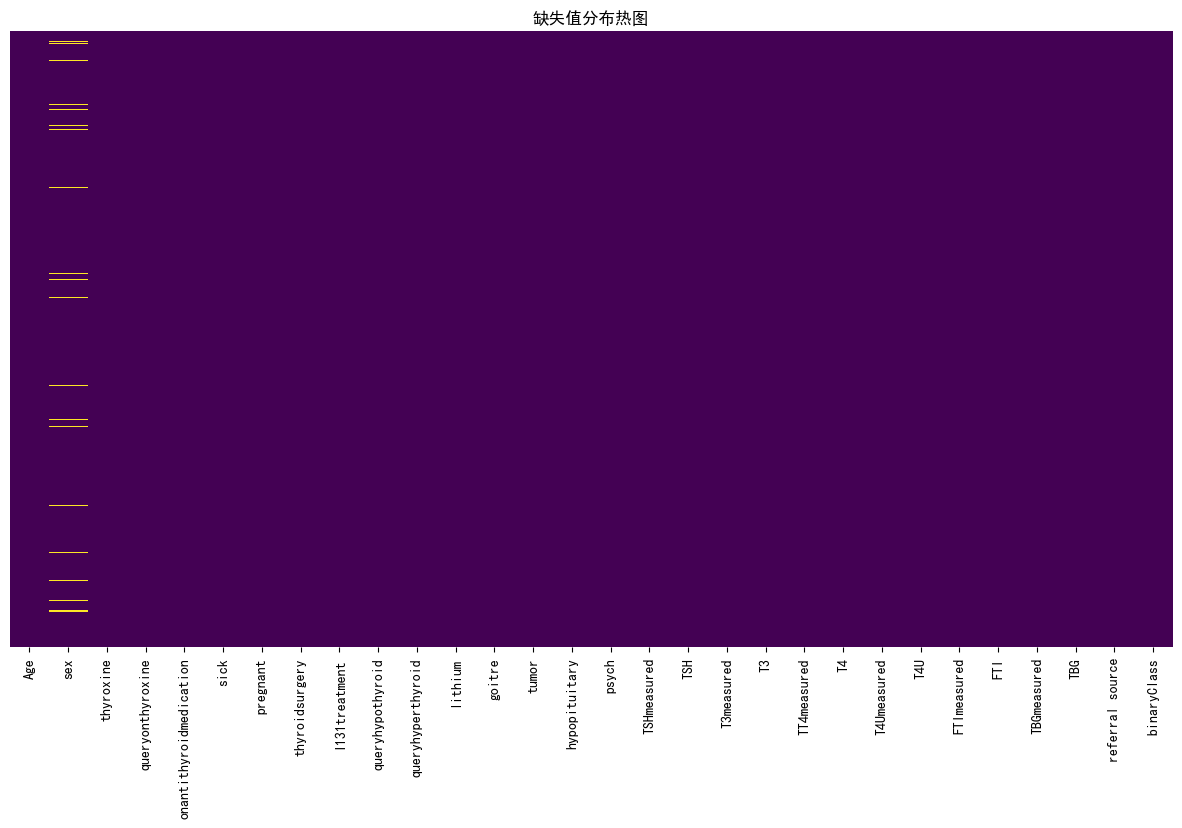

In [326]:
print("绘制缺失值热图...")
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('缺失值分布热图')
plt.show()

##### 箱线图

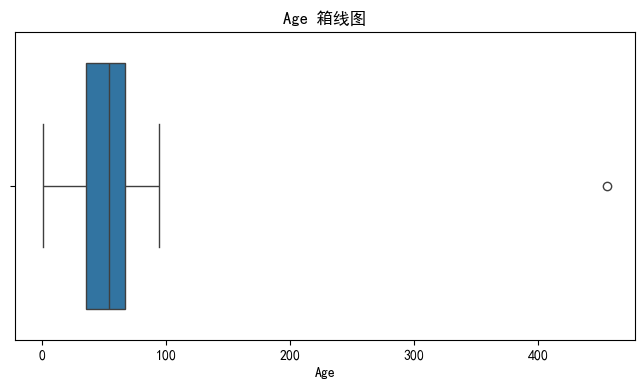

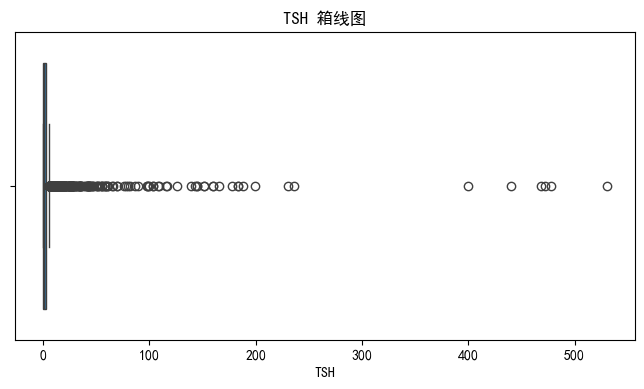

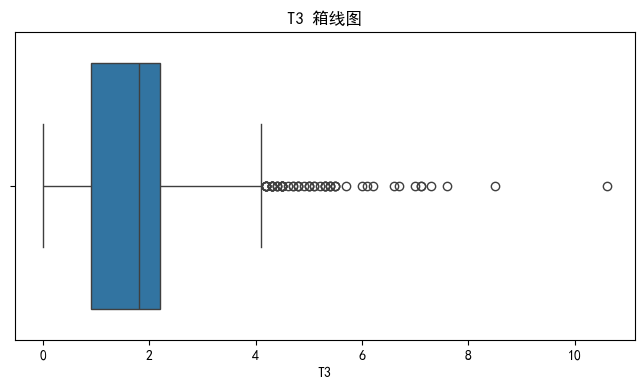

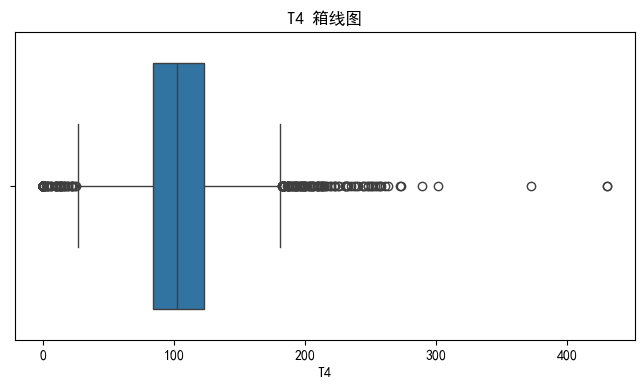

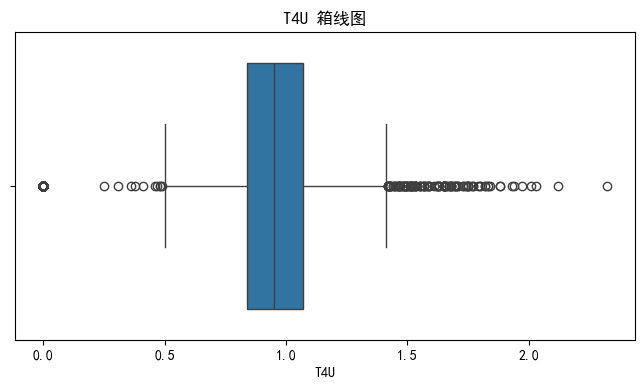

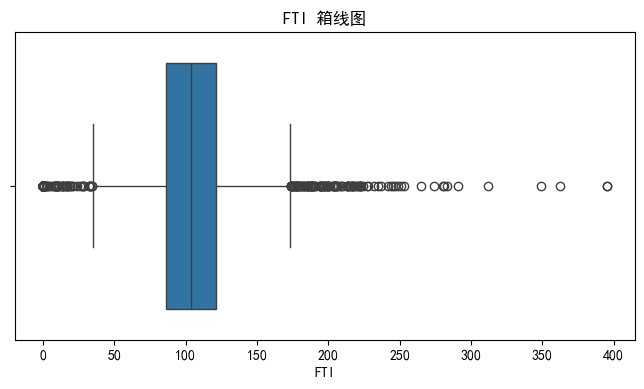

In [327]:
def boxplot_numeric(col):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} 箱线图")
    plt.show()

for col in num_cols:
    boxplot_numeric(col)


##### 删除低方差列

In [328]:
# 设定方差阈值
from sklearn.feature_selection import VarianceThreshold

var_thresh = VarianceThreshold(threshold=0.1)
var_thresh.fit(df[num_cols])
# 选择高方差特征
high_var_features = df[num_cols].columns[var_thresh.get_support()]
print('删除低方差列之前的列数',len(num_cols))
print('删除低方差列之后的列数',len(high_var_features))

删除低方差列之前的列数 6
删除低方差列之后的列数 6


In [329]:
num_cols

['Age', 'TSH', 'T3', 'T4', 'T4U', 'FTI']

In [330]:
high_var_features

Index(['Age', 'TSH', 'T3', 'T4', 'T4U', 'FTI'], dtype='object')

##### 处理离群值

In [331]:
def outlier_thresholds(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def check_outliers(data, col):
    lower, upper = outlier_thresholds(data, col)
    return data[(data[col] < lower) | (data[col] > upper)]

for col in high_var_features:
    print(f"{col} 异常值数量:", len(check_outliers(df, col)))

Age 异常值数量: 1
TSH 异常值数量: 376
T3 异常值数量: 61
T4 异常值数量: 397
T4U 异常值数量: 521
FTI 异常值数量: 561


#### 离群值处理前后对比（选择1个核心数值特征示例）

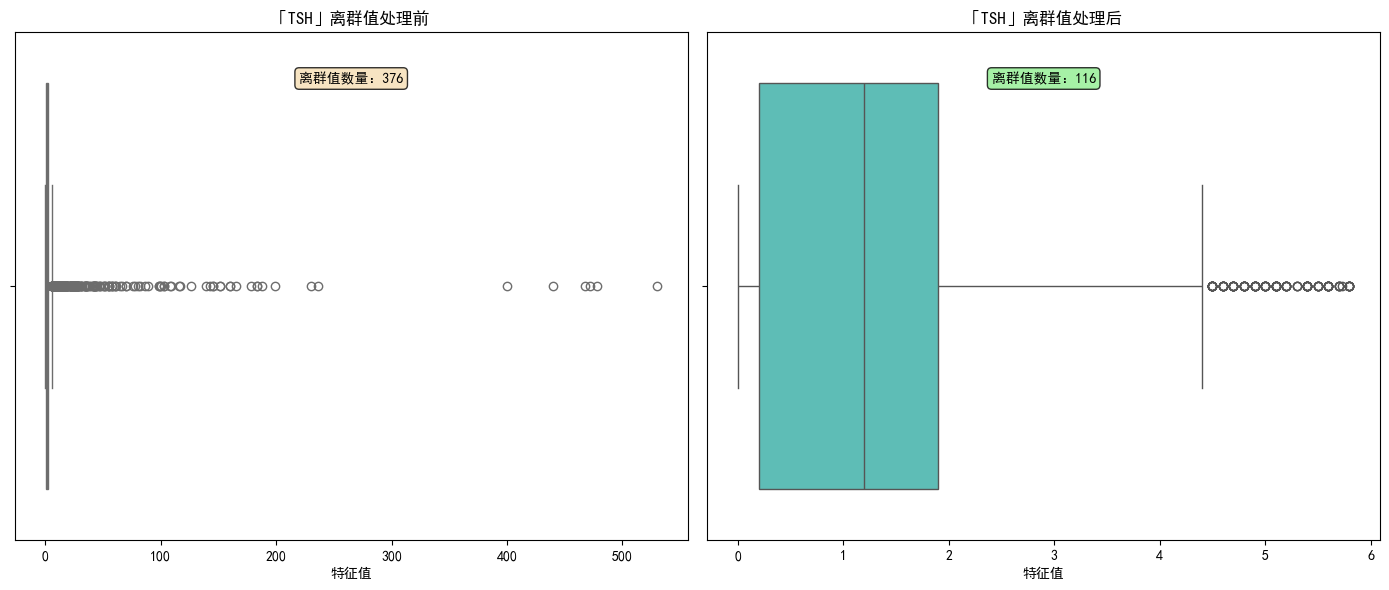

In [332]:
if len(high_var_features) > 0:
    sample_num_col = high_var_features[1]
    # 保存处理前的数据（深拷贝避免污染）
    df_before_outlier = df.copy()
    # 重新执行一次离群值处理（仅用于对比）
    replace_outliers_with_median(df_before_outlier, sample_num_col)
    
    # 创建子图对比
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 处理前的箱线图
    sns.boxplot(x=df[sample_num_col], ax=ax1, color='#FF6B6B')
    ax1.set_title(f'「{sample_num_col}」离群值处理前', fontsize=12, fontweight='bold')
    ax1.set_xlabel('特征值', fontsize=10)
    # 标注离群值数量
    outlier_count_before = len(check_outliers(df, sample_num_col))
    ax1.text(0.5, 0.9, f'离群值数量：{outlier_count_before}', 
             transform=ax1.transAxes, ha='center', fontsize=10, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # 处理后的箱线图
    sns.boxplot(x=df_before_outlier[sample_num_col], ax=ax2, color='#4ECDC4')
    ax2.set_title(f'「{sample_num_col}」离群值处理后', fontsize=12, fontweight='bold')
    ax2.set_xlabel('特征值', fontsize=10)
    # 标注处理后离群值数量（理论上为0）
    outlier_count_after = len(check_outliers(df_before_outlier, sample_num_col))
    ax2.text(0.5, 0.9, f'离群值数量：{outlier_count_after}', 
             transform=ax2.transAxes, ha='center', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

In [333]:
def replace_outliers_with_median(data, col):
    lower, upper = outlier_thresholds(data, col)
    median = data[col].median()
    data[col] = np.where((data[col] < lower) | (data[col] > upper), median, data[col])

for col in high_var_features:
    replace_outliers_with_median(df, col)

##### 填补空值

In [334]:
from sklearn.impute import KNNImputer

# 假设 high_var_features 是你要填充的特征列
imputer = KNNImputer(n_neighbors=5)  # 设置 KNN 的邻居数量

# 使用 KNN 填充缺失值
df[high_var_features] = imputer.fit_transform(df[high_var_features])

# 检查填充后的缺失值数量
df[high_var_features].isnull().sum().sort_values(ascending=False).head(10)

Age    0
TSH    0
T3     0
T4     0
T4U    0
FTI    0
dtype: int64

In [335]:
df.isnull().sum().sort_values(ascending=False).head(10)

sex                        150
Age                          0
thyroxine                    0
queryonthyroxine             0
onantithyroidmedication      0
sick                         0
pregnant                     0
thyroidsurgery               0
I131treatment                0
queryhypothyroid             0
dtype: int64

##### 绘制初步处理后的分布图和箱线图

count    3770.000000
mean       51.618568
std        18.993858
min         1.000000
25%        36.000000
50%        54.000000
75%        67.000000
max        94.000000
Name: Age, dtype: float64


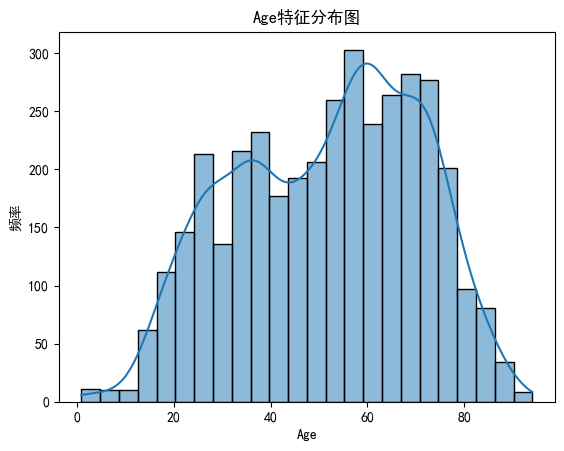

count    3770.000000
mean        1.278850
std         1.228763
min         0.000000
25%         0.200000
50%         1.200000
75%         1.900000
max         5.800000
Name: TSH, dtype: float64


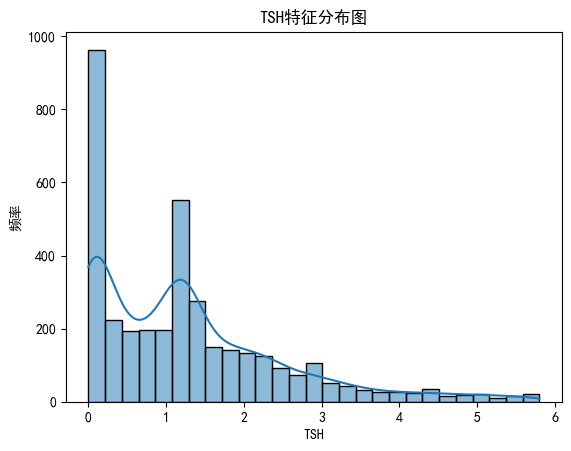

count    3770.000000
mean        1.547570
std         0.982642
min         0.000000
25%         0.900000
50%         1.800000
75%         2.200000
max         4.100000
Name: T3, dtype: float64


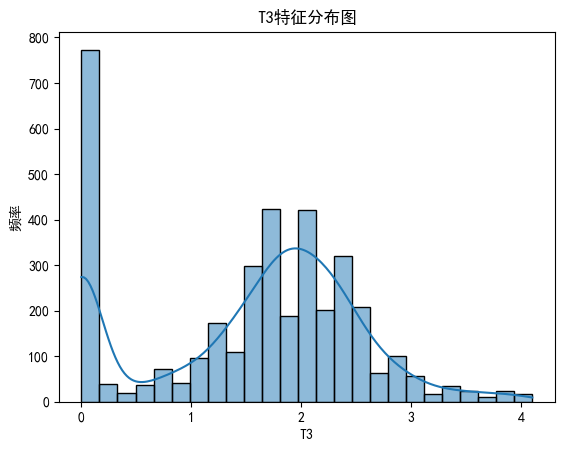

count    3770.000000
mean      105.150928
std        25.583585
min        27.000000
25%        90.000000
50%       102.000000
75%       120.000000
max       181.000000
Name: T4, dtype: float64


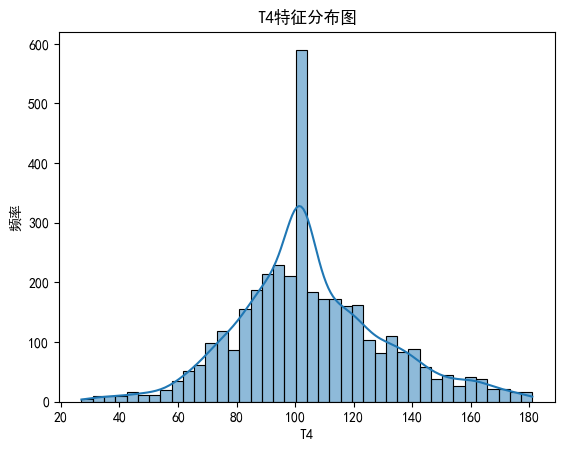

count    3770.000000
mean        0.969908
std         0.139244
min         0.500000
25%         0.890000
50%         0.950000
75%         1.050000
max         1.410000
Name: T4U, dtype: float64


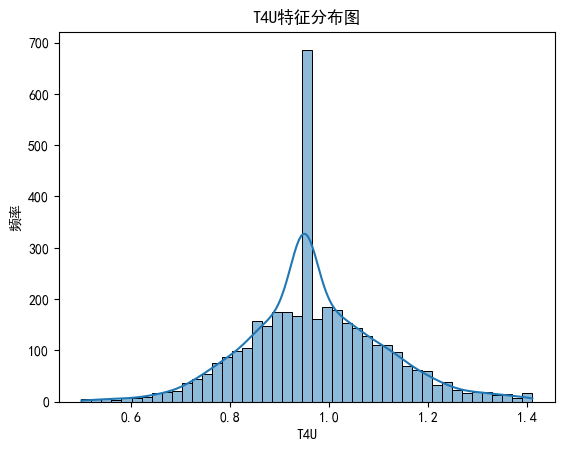

count    3770.000000
mean      107.313263
std        21.747722
min        35.000000
25%        95.000000
50%       104.000000
75%       118.000000
max       173.000000
Name: FTI, dtype: float64


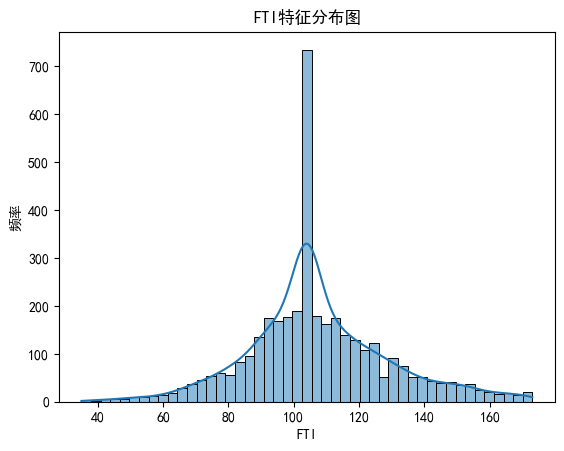

In [336]:
def summary_numeric(col):
    print(df[col].describe())
    sns.histplot(df[col], kde=True)
    plt.title(f'{col}特征分布图')
    plt.xlabel(col)
    plt.ylabel('频率')
    plt.show()

for col in high_var_features:
    summary_numeric(col)

#### 箱线图

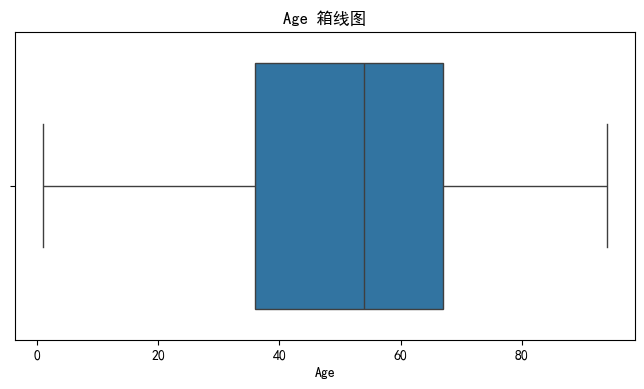

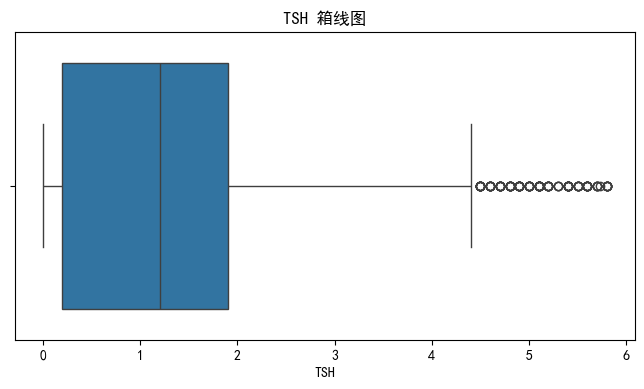

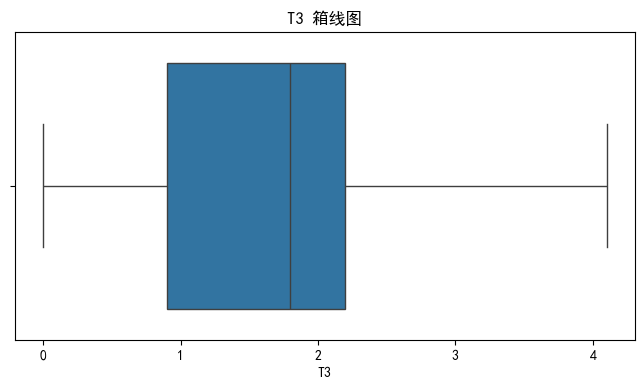

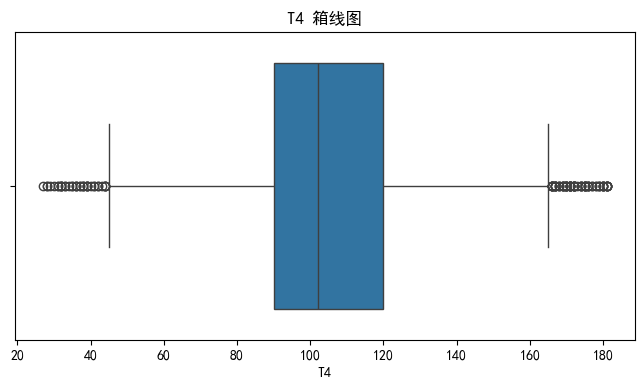

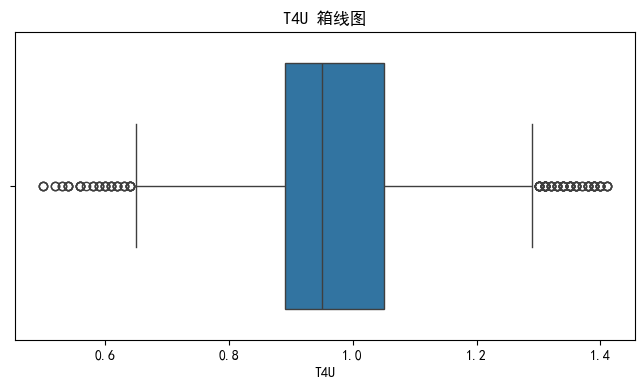

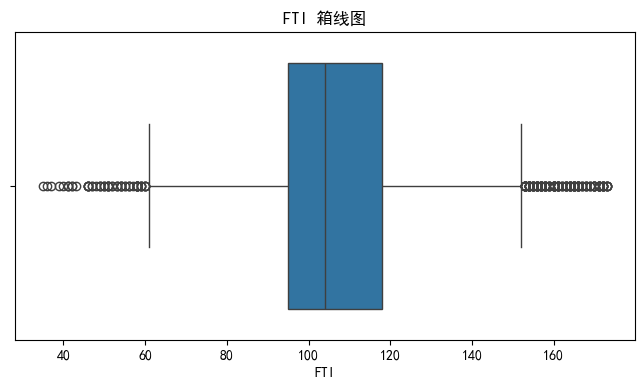

In [337]:
def boxplot_numeric(col):
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"{col} 箱线图")
    plt.show()

for col in high_var_features:
    boxplot_numeric(col)

#### 分析分类特征

##### 查看唯一值

In [338]:
df[cat_cols].nunique()

sex                        2
thyroxine                  2
queryonthyroxine           2
onantithyroidmedication    2
sick                       2
pregnant                   2
thyroidsurgery             2
I131treatment              2
queryhypothyroid           2
queryhyperthyroid          2
lithium                    2
goitre                     2
tumor                      2
hypopituitary              2
psych                      2
TSHmeasured                2
T3measured                 2
TT4measured                2
T4Umeasured                2
FTImeasured                2
TBGmeasured                1
TBG                        1
referral source            5
binaryClass                2
dtype: int64

##### 编码

In [339]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

def encode_categorical_columns(df):
    """
    对分类列进行编码处理
    - 二分类变量：使用标签编码
    - 多分类变量：使用独热编码并转换为整数类型
    """

    label_encoder = LabelEncoder()

    for col in df.select_dtypes(include=['object', 'category']).columns:
        unique_vals = df[col].nunique()

        if unique_vals == 2 or unique_vals == 1:
            # 标签编码
            df[col] = label_encoder.fit_transform(df[col])
        elif unique_vals > 2:
            # 独热编码 + 从布尔值转换为整数
            dummies = pd.get_dummies(df[col], prefix=col).astype(int)
            df = pd.concat([df.drop(col, axis=1), dummies], axis=1)

    return df

#### 特征重要性累积占比曲线

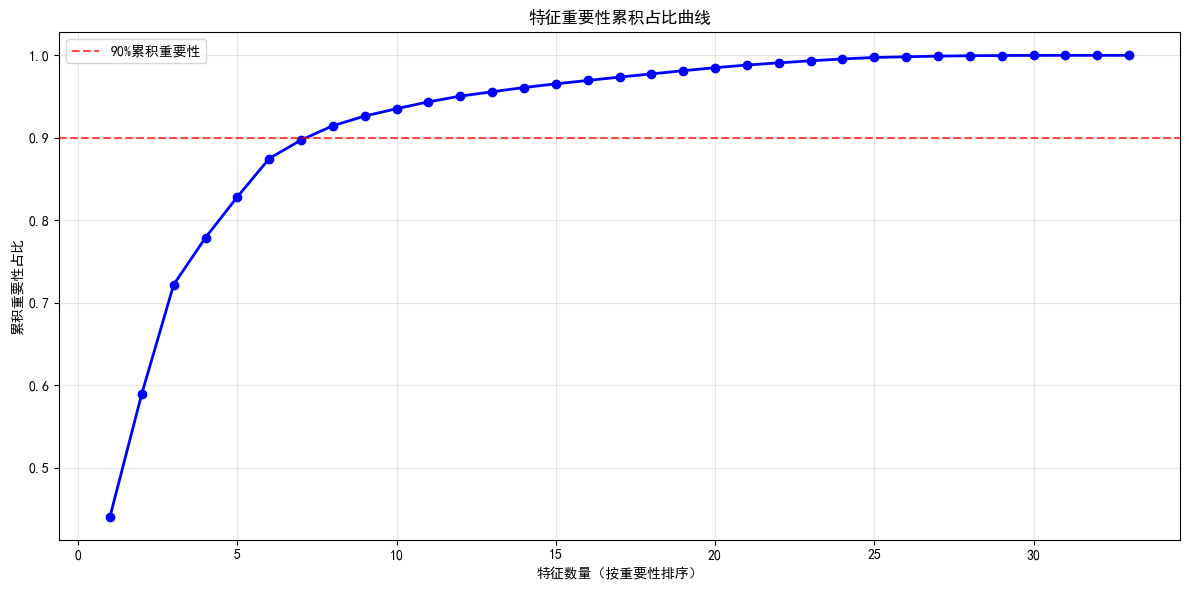

前 8 个特征贡献了90%的重要性


In [376]:
from sklearn.ensemble import RandomForestClassifier
rf_importance = RandomForestClassifier(n_estimators=50, max_depth=8, random_state=42)
rf_importance.fit(X, y)  # 确保X和y已正确定义

# 计算累积重要性
feature_importance = pd.DataFrame({
    '特征名称': X.columns,
    '重要性': rf_importance.feature_importances_
})
sorted_importance = feature_importance.sort_values('重要性', ascending=False)
sorted_importance['累积重要性'] = sorted_importance['重要性'].cumsum() / sorted_importance['重要性'].sum()

# 绘制累积重要性曲线
plt.figure(figsize=(12, 6))
plt.plot(range(1, len(sorted_importance) + 1), sorted_importance['累积重要性'], 
         marker='o', color='b', linewidth=2, markersize=6)
plt.axhline(y=0.9, color='r', linestyle='--', alpha=0.7, label='90%累积重要性')
plt.xlabel('特征数量（按重要性排序）')
plt.ylabel('累积重要性占比')
plt.title('特征重要性累积占比曲线')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 输出关键节点信息
n_90 = len(sorted_importance[sorted_importance['累积重要性'] <= 0.9]) + 1
print(f"前 {n_90} 个特征贡献了90%的重要性")

#### 分类特征编码前后维度对比

DataFrame中的列名:
['Age', 'sex', 'thyroxine', 'queryonthyroxine', 'onantithyroidmedication', 'sick', 'pregnant', 'thyroidsurgery', 'I131treatment', 'queryhypothyroid', 'queryhyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSHmeasured', 'TSH', 'T3measured', 'T3', 'TT4measured', 'T4', 'T4Umeasured', 'T4U', 'FTImeasured', 'FTI', 'TBGmeasured', 'TBG', 'referral source', 'binaryClass']

cat_cols中的列名:
['sex', 'thyroxine', 'queryonthyroxine', 'onantithyroidmedication', 'sick', 'pregnant', 'thyroidsurgery', 'I131treatment', 'queryhypothyroid', 'queryhyperthyroid', 'lithium', 'goitre', 'tumor', 'hypopituitary', 'psych', 'TSHmeasured', 'T3measured', 'TT4measured', 'T4Umeasured', 'FTImeasured', 'TBGmeasured', 'TBG', 'referral source', 'binaryClass']

cat_cols中存在但DataFrame中不存在的列:
[]


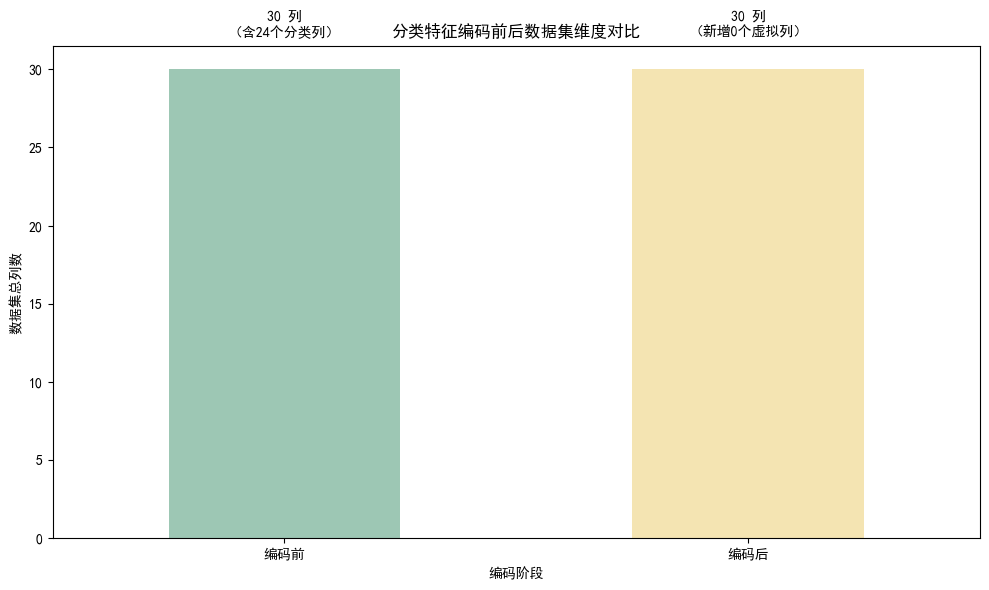

📋 分类特征编码详情：
- 特征「sex」：二分类/单分类 → 标签编码（保留原列）
- 特征「thyroxine」：二分类/单分类 → 标签编码（保留原列）
- 特征「queryonthyroxine」：二分类/单分类 → 标签编码（保留原列）
- 特征「onantithyroidmedication」：二分类/单分类 → 标签编码（保留原列）
- 特征「sick」：二分类/单分类 → 标签编码（保留原列）
- 特征「pregnant」：二分类/单分类 → 标签编码（保留原列）
- 特征「thyroidsurgery」：二分类/单分类 → 标签编码（保留原列）
- 特征「I131treatment」：二分类/单分类 → 标签编码（保留原列）
- 特征「queryhypothyroid」：二分类/单分类 → 标签编码（保留原列）
- 特征「queryhyperthyroid」：二分类/单分类 → 标签编码（保留原列）
- 特征「lithium」：二分类/单分类 → 标签编码（保留原列）
- 特征「goitre」：二分类/单分类 → 标签编码（保留原列）
- 特征「tumor」：二分类/单分类 → 标签编码（保留原列）
- 特征「hypopituitary」：二分类/单分类 → 标签编码（保留原列）
- 特征「psych」：二分类/单分类 → 标签编码（保留原列）
- 特征「TSHmeasured」：二分类/单分类 → 标签编码（保留原列）
- 特征「T3measured」：二分类/单分类 → 标签编码（保留原列）
- 特征「TT4measured」：二分类/单分类 → 标签编码（保留原列）
- 特征「T4Umeasured」：二分类/单分类 → 标签编码（保留原列）
- 特征「FTImeasured」：二分类/单分类 → 标签编码（保留原列）
- 特征「TBGmeasured」：二分类/单分类 → 标签编码（保留原列）
- 特征「TBG」：多分类 → 独热编码（生成 2 个虚拟列）
- 特征「referral source」：二分类/单分类 → 标签编码（保留原列）
- 特征「binaryClass」：二分类/单分类 → 标签编码（保留原列）


In [340]:
# 首先检查DataFrame中的实际列名
print("DataFrame中的列名:")
print(df.columns.tolist())

# 检查cat_cols中包含哪些列
print("\ncat_cols中的列名:")
print(cat_cols)

# 找出cat_cols中存在但DataFrame中不存在的列
missing_cols = [col for col in cat_cols if col not in df.columns]
print("\ncat_cols中存在但DataFrame中不存在的列:")
print(missing_cols)

# 确保cat_cols只包含DataFrame中实际存在的列
cat_cols_existing = [col for col in cat_cols if col in df.columns]

cols_before_encode = df.columns.tolist()
cols_count_before = len(cols_before_encode)
# 统计编码前分类特征的总类别数（只使用实际存在的列）
total_categories_before = sum([df[col].nunique(dropna=False) for col in cat_cols_existing])

# 编码后的列名和数量（直接使用编码后的df）
cols_after_encode = df.columns.tolist()
cols_count_after = len(cols_after_encode)
# 统计编码后新增的列数（独热编码生成的虚拟列）
added_cols_count = cols_count_after - cols_count_before

# 绘制维度对比柱状图
plt.figure(figsize=(10, 6))
x = ['编码前', '编码后']
y = [cols_count_before, cols_count_after]
bars = sns.barplot(x=x, y=y, palette=['#96CEB4', '#FFEAA7'], width=0.5)
plt.title('分类特征编码前后数据集维度对比', fontsize=12, fontweight='bold')
plt.ylabel('数据集总列数', fontsize=10)
plt.xlabel('编码阶段', fontsize=10)

# 在柱子上添加具体数值和备注
bars.text(0, cols_count_before + 2, f'{cols_count_before} 列\n（含{len(cat_cols_existing)}个分类列）', 
          ha='center', va='bottom', fontsize=10)
bars.text(1, cols_count_after + 2, f'{cols_count_after} 列\n（新增{added_cols_count}个虚拟列）', 
          ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# 输出编码详情（只使用实际存在的列）
print("📋 分类特征编码详情：")
for col in cat_cols_existing:
    # 查找编码后对应的列（标签编码：原列名保留；独热编码：前缀为原列名）
    encoded_cols = [c for c in cols_after_encode if c.startswith(col)]
    if len(encoded_cols) == 1 and encoded_cols[0] == col:
        print(f"- 特征「{col}」：二分类/单分类 → 标签编码（保留原列）")
    else:
        print(f"- 特征「{col}」：多分类 → 独热编码（生成 {len(encoded_cols)} 个虚拟列）")


In [341]:
df = encode_categorical_columns(df)

In [342]:
df.isnull().sum().sort_values(ascending=False).head()

Age                        0
sex                        0
thyroxine                  0
queryonthyroxine           0
onantithyroidmedication    0
dtype: int64

#### 相关性热力图

绘制相关性热力图...


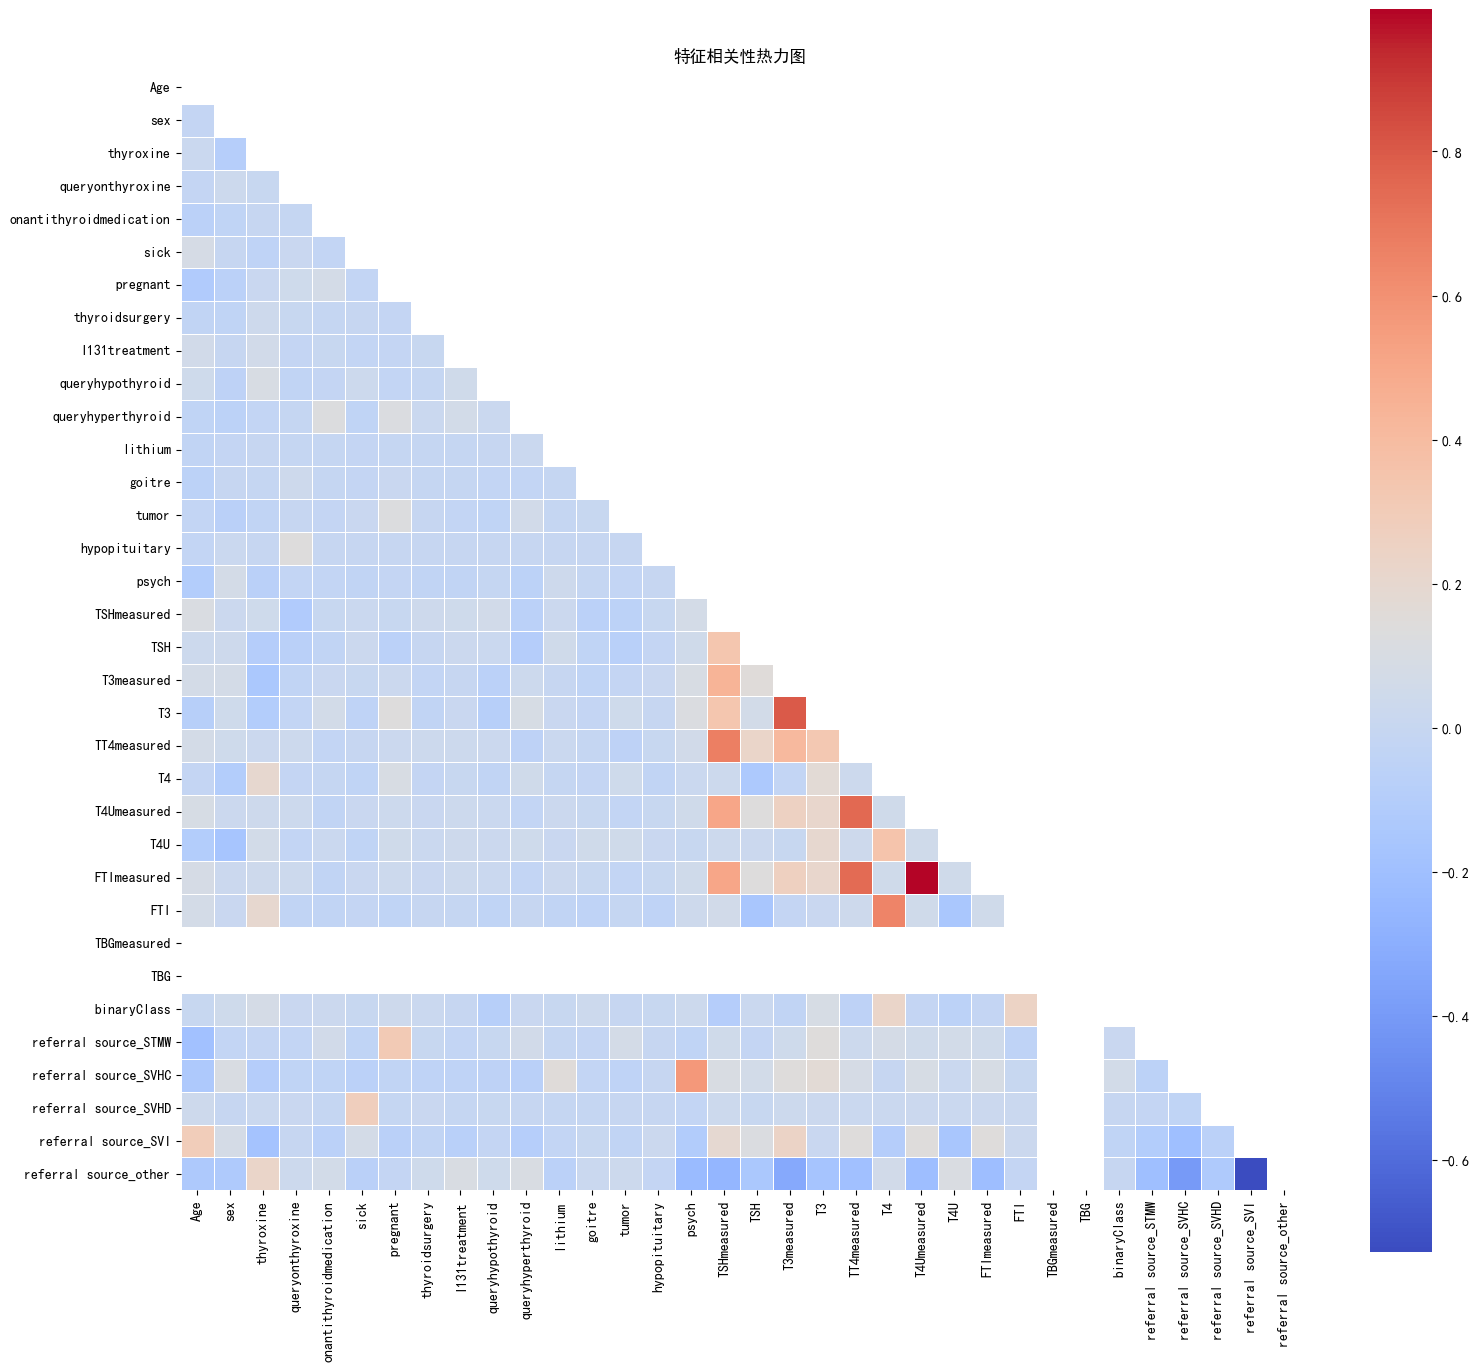

In [343]:
print("绘制相关性热力图...")
corr_matrix = df.corr()
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', linewidths=0.5, square=True)
plt.title('特征相关性热力图')
plt.tight_layout()
plt.show()

#### 最终预处理后数据概览

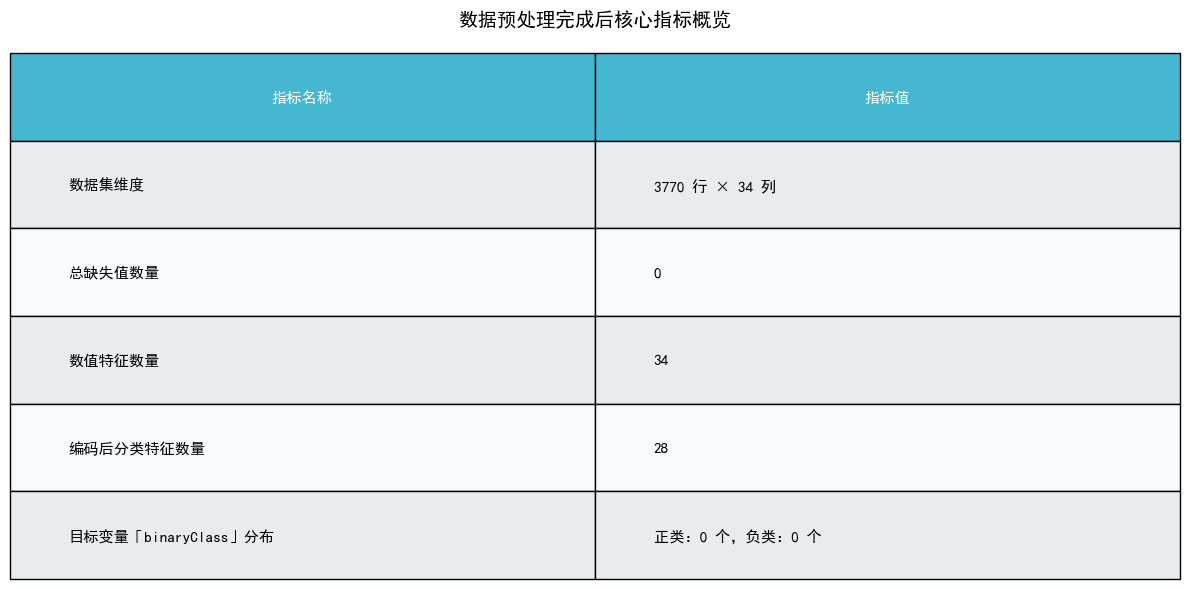

✅ 预处理完成：数据无缺失值，可进入模型训练阶段


In [344]:
final_missing_count = df.isnull().sum().sum()  # 总缺失值数量
final_num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
final_cat_encoded_cols = df.select_dtypes(include=['int64']).columns.tolist()  # 编码后的分类列（整数型）
final_dimension = df.shape

# 计算目标变量分布
# 根据y的实际类型选择合适的方法
if isinstance(y, pd.Series):
    # 如果y是Pandas Series
    positive_count = (y == 1).sum()
    negative_count = (y == 0).sum()
elif isinstance(y, np.ndarray):
    # 如果y是NumPy数组
    positive_count = (y == 1).sum()
    negative_count = (y == 0).sum()
elif isinstance(y, list):
    # 如果y是列表
    positive_count = y.count(1)
    negative_count = y.count(0)
else:
    # 其他情况，尝试通用方法
    try:
        positive_count = sum(1 for val in y if val == 1)
        negative_count = sum(1 for val in y if val == 0)
    except:
        positive_count = "未知"
        negative_count = "未知"

# 创建概览表格并可视化
metrics = [
    ['数据集维度', f'{final_dimension[0]} 行 × {final_dimension[1]} 列'],
    ['总缺失值数量', final_missing_count],
    ['数值特征数量', len(final_num_cols)],
    ['编码后分类特征数量', len(final_cat_encoded_cols)],
    ['目标变量「binaryClass」分布', f'正类：{positive_count} 个，负类：{negative_count} 个']
]

# 转换为DataFrame便于绘图
metrics_df = pd.DataFrame(metrics, columns=['指标名称', '指标值'])

# 绘制指标展示图
plt.figure(figsize=(12, 6))
# 用表格形式展示（更清晰）
ax = plt.subplot(111, frame_on=False)
ax.xaxis.set_visible(False)
ax.yaxis.set_visible(False)
# 创建表格
table = ax.table(cellText=metrics_df.values, colLabels=metrics_df.columns,
                 cellLoc='left', loc='center', bbox=[0, 0, 1, 1])
# 设置表格样式
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)  # 调整表格大小
# 设置表头和内容的颜色
for i in range(len(metrics_df.columns)):
    table[(0, i)].set_facecolor('#45B7D1')
    table[(0, i)].set_text_props(weight='bold', color='white')
for i in range(1, len(metrics_df) + 1):
    for j in range(len(metrics_df.columns)):
        table[(i, j)].set_facecolor('#F8F9FA' if i % 2 == 0 else '#E9ECEF')

plt.title('数据预处理完成后核心指标概览', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 验证数据是否可用
if final_missing_count == 0:
    print("✅ 预处理完成：数据无缺失值，可进入模型训练阶段")
else:
    print(f"⚠️  预处理后仍存在 {final_missing_count} 个缺失值，请检查填充逻辑")

### 预处理结果

In [345]:
y = df['binaryClass']
X = df.drop(['binaryClass'], axis=1)

###  模型训练

#### 准备复用函数

In [346]:
# 混淆矩阵函数
def plot_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('预测标签')
    plt.ylabel('真实标签')
    plt.title('混淆矩阵')
    plt.show()

In [347]:
# 基础评分
from sklearn.metrics import recall_score

def print_model_scores(pipe, X_test, y_test):
    print("模型得分:", pipe.score(X_test, y_test))
    print("召回率:", recall_score(y_test, pipe.predict(X_test)))
    print("AUC评分:", roc_auc_score(y_test, pipe.predict_proba(X_test)[:, 1]))


In [348]:
# 常用指标函数
def print_classification_report(y_true, y_pred):
    print("分类报告:\n", classification_report(y_true, y_pred))

In [349]:
# 绘制ROC曲线函数
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

def plot_roc_curve(y_true, y_pred_probs):
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label='ROC曲线 (AUC = {:.2f})'.format(auc(fpr, tpr)))
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('假阳性率')
    plt.ylabel('真阳性率')
    plt.title('ROC曲线')
    plt.legend()
    plt.show()

In [350]:
# 绘制PR曲线函数
from sklearn.metrics import precision_recall_curve

def plot_pr_curve(y_true, y_pred_probs):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred_probs)
    plt.figure(figsize=(8, 6))
    plt.plot(recall, precision, label='PR曲线 (AUC = {:.2f})'.format(auc(recall, precision)))
    plt.xlabel('召回率')
    plt.ylabel('精确率')
    plt.title('PR曲线')
    plt.legend()
    plt.show()

In [351]:
from sklearn.metrics import precision_score, recall_score


def evaluate_model(model, X_train, y_train, X_test, y_test, model_name, cv=5):
    
    # 在测试集上评估
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f'\n{model_name} 测试集评估结果:')
    print(f'准确率: {accuracy:.4f}')
    print(f'精确率: {precision:.4f}')
    print(f'召回率: {recall:.4f}')
    
    # 交叉验证评估
    print(f'\n{model_name} 交叉验证结果 (cv={cv}):')
    # 交叉验证准确率
    cv_accuracy = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f'交叉验证准确率: {cv_accuracy.mean():.4f} (±{cv_accuracy.std():.4f})')
    
    # 交叉验证精确率
    cv_precision = cross_val_score(model, X_train, y_train, cv=cv, scoring='precision')
    print(f'交叉验证精确率: {cv_precision.mean():.4f} (±{cv_precision.std():.4f})')
    
    # 交叉验证召回率
    cv_recall = cross_val_score(model, X_train, y_train, cv=cv, scoring='recall')
    print(f'交叉验证召回率: {cv_recall.mean():.4f} (±{cv_recall.std():.4f})')
    
    # 返回所有评估指标
    return {
        'test_accuracy': accuracy,
        'test_precision': precision,
        'test_recall': recall,
        'cv_accuracy': (cv_accuracy.mean(), cv_accuracy.std()),
        'cv_precision': (cv_precision.mean(), cv_precision.std()),
        'cv_recall': (cv_recall.mean(), cv_recall.std())
    }

#### 切割数据集

In [352]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

#### XGBoost模型

模型得分: 0.9761273209549072
召回率: 0.9816124469589816
AUC评分: 0.9940112552288664


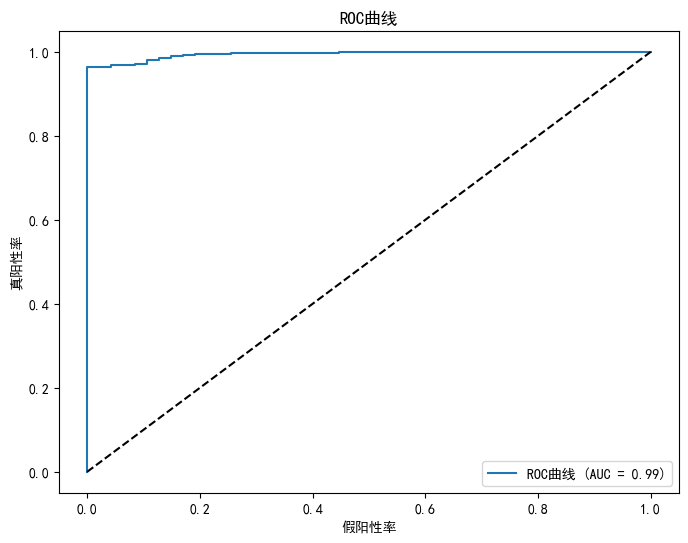

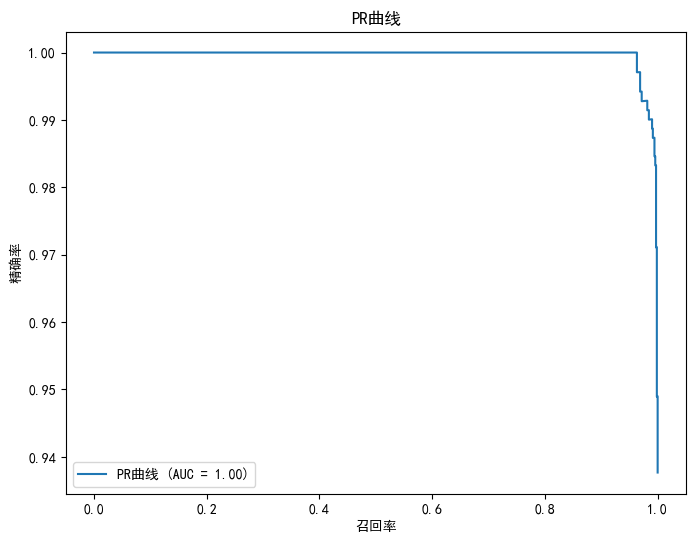

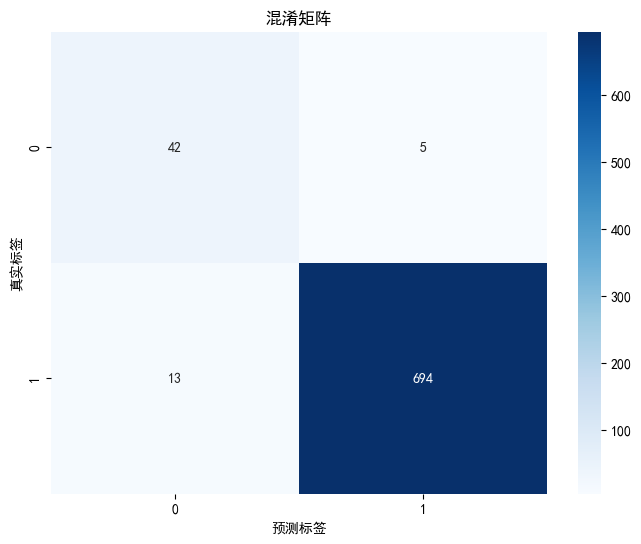

In [366]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

xgb_model = XGBClassifier(use_label_encoder=False, eval_metric="logloss")
pipe_xgb = Pipeline([
    ("scaler", StandardScaler()),
    ("XGB", xgb_model)
])
pipe_xgb.fit(X_train, y_train)

print_model_scores(pipe_xgb, X_test, y_test)
plot_roc_curve(y_test, pipe_xgb.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_xgb.predict_proba(X_test)[:, 1])
y_pred_xgb = pipe_xgb.predict(X_test)
plot_confusion_matrix(y_test, y_pred_xgb)

##### 处理数据集不平衡问题

In [354]:
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import train_test_split
# from xgboost import XGBClassifier
# from sklearn.metrics import recall_score, roc_auc_score

# # 计算正负样本比例
# negative_count = len(y[y == 1])
# positive_count = len(y[y == 0])
# scale_pos_weight = negative_count / positive_count

# print(f"负样本数: {negative_count}, 正样本数: {positive_count}")
# print(f"scale_pos_weight: {scale_pos_weight}")

# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# xgb_model = XGBClassifier(
#     use_label_encoder=False, 
#     eval_metric="logloss",
#     scale_pos_weight=scale_pos_weight,  # 关键参数
#     random_state=42
# )

# pipe_xgb = Pipeline([
#     ("scaler", StandardScaler()),
#     ("XGB", xgb_model)
# ])

# pipe_xgb.fit(X_train, y_train)
# print("模型得分:", pipe_xgb.score(X_test, y_test))
# print("召回率:", recall_score(y_test, pipe_xgb.predict(X_test), pos_label=1))
# print("AUC评分:", roc_auc_score(y_test, pipe_xgb.predict_proba(X_test)[:, 1]))

#### LightGBM模型

模型得分: 0.9761273209549072
召回率: 0.9801980198019802
AUC评分: 0.9937705016702277


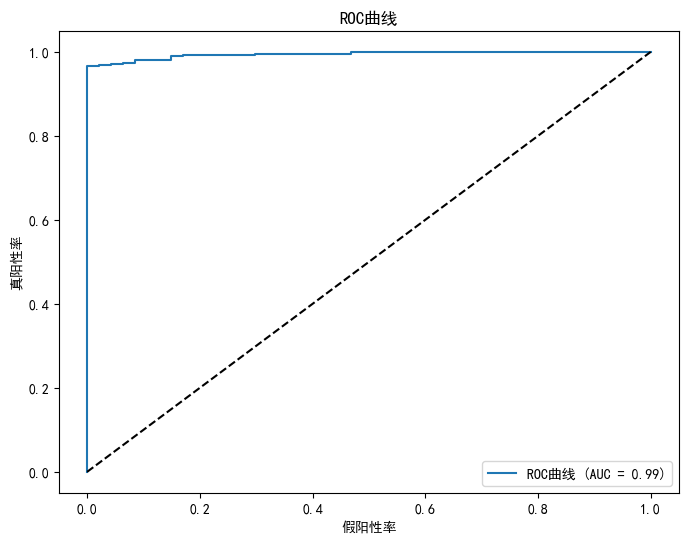

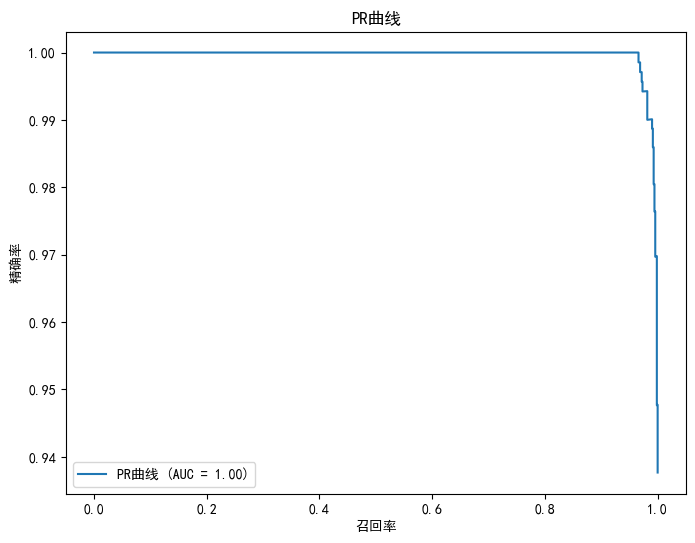

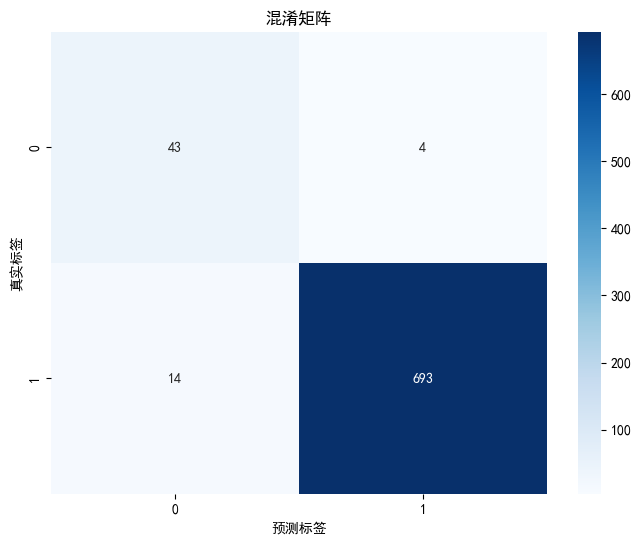

In [367]:
from sklearn.metrics import recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")
warnings.filterwarnings("ignore", category=FutureWarning, module="lightgbm")
warnings.filterwarnings("ignore", message=".*LightGBM.*")
import os
os.environ['PYTHONWARNINGS'] = 'ignore::UserWarning:lightgbm'
lgbm_model = LGBMClassifier(
    random_state=42,
    verbose=-1,  # 完全静默模式
    force_col_wise=True,  # 强制列式多线程，避免overhead警告
    objective='binary',
    boosting_type='gbdt',
    num_leaves=31,
    learning_rate=0.05,
    feature_fraction=0.9
)


pipe_lgbm = Pipeline([
    ("scaler", StandardScaler()),
    ("LGBM", lgbm_model)
])
pipe_lgbm.fit(X_train, y_train)

print_model_scores(pipe_lgbm, X_test, y_test)
plot_roc_curve(y_test, pipe_lgbm.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_lgbm.predict_proba(X_test)[:, 1])
y_pred_lgbm = pipe_lgbm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_lgbm)

#### KNN

模型得分: 0.9310344827586207
召回率: 0.9787835926449788
AUC评分: 0.7830960907640916


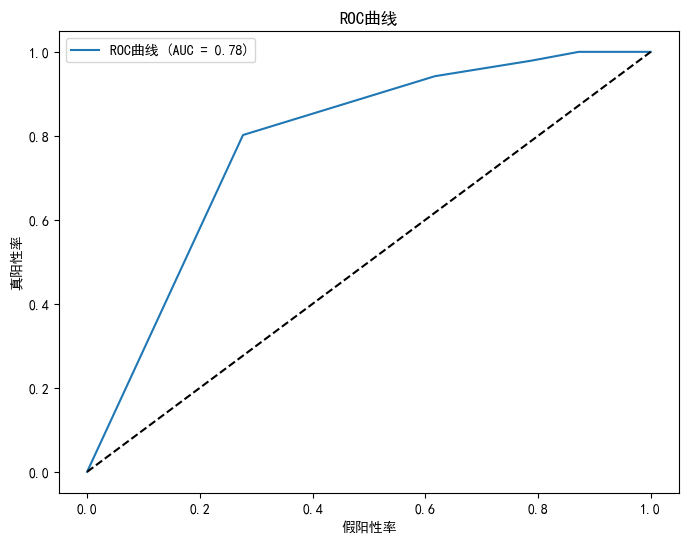

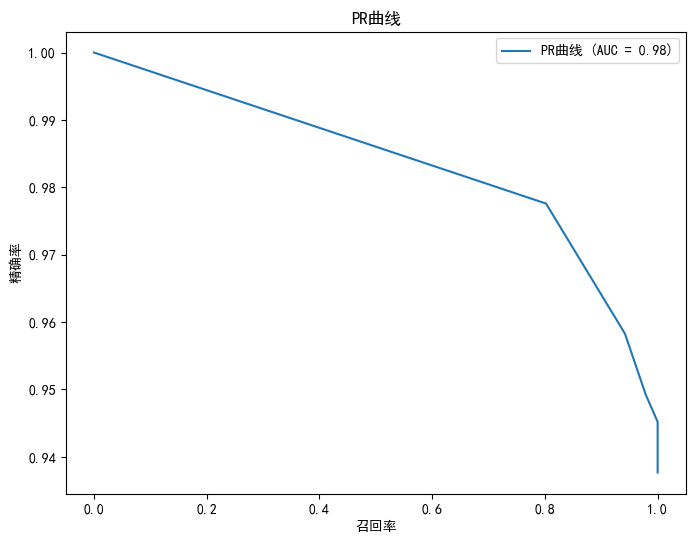

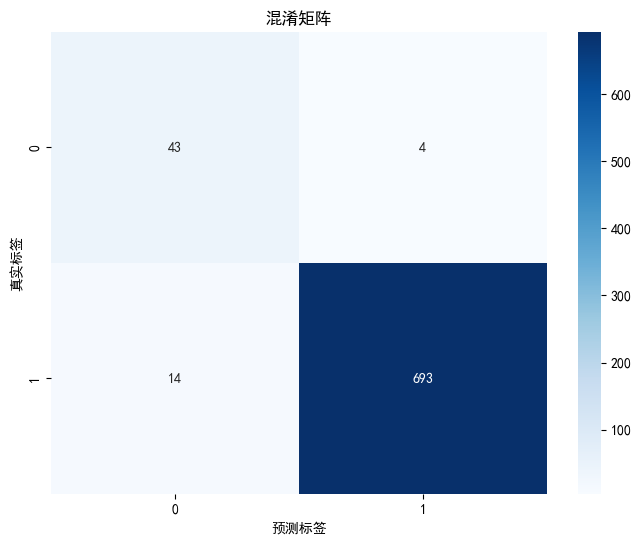

In [368]:
# K-近邻算法
import sklearn.neighbors as neighbors

knn_model = neighbors.KNeighborsClassifier()
pipe_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("KNN", knn_model)
])
pipe_knn.fit(X_train, y_train)

print_model_scores(pipe_knn, X_test, y_test)
plot_roc_curve(y_test, pipe_knn.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_knn.predict_proba(X_test)[:, 1])
y_pred_lgbm = pipe_lgbm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_lgbm)

#### SVM

模型得分: 0.9389920424403183
召回率: 1.0
AUC评分: 0.8336693851755997


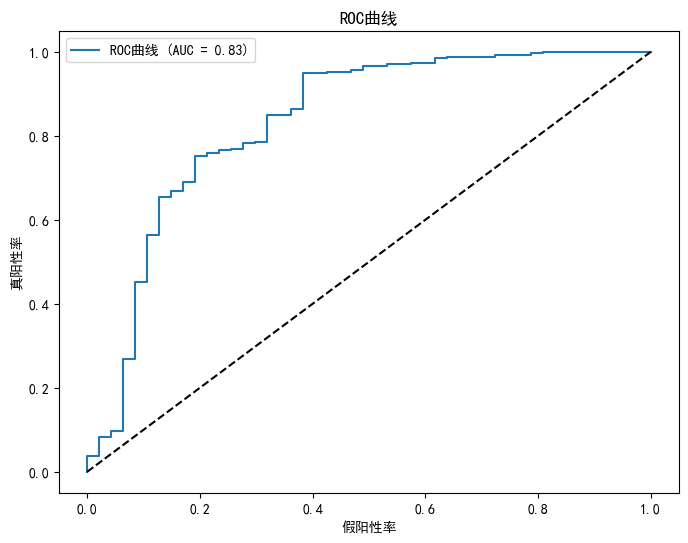

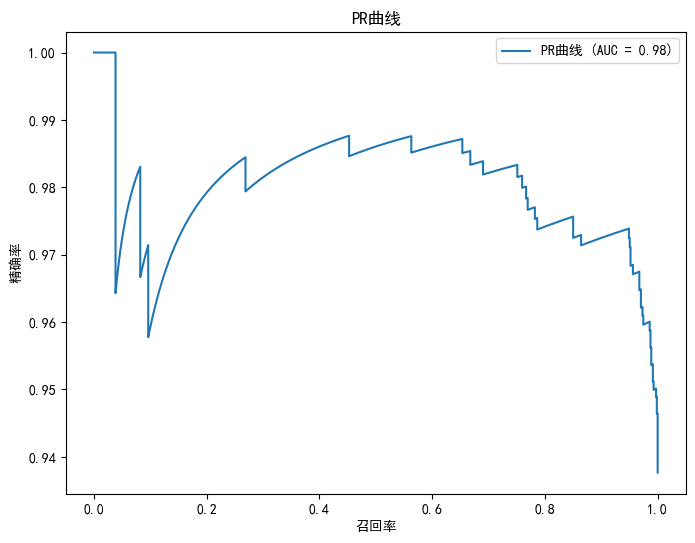

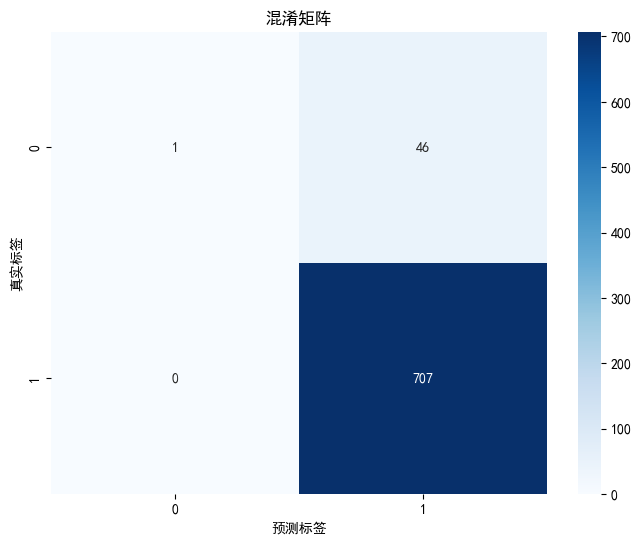

In [369]:
from sklearn.svm import SVC

svm_model = SVC(probability=True)
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("SVM", svm_model)
])
pipe_svm.fit(X_train, y_train)

print_model_scores(pipe_svm, X_test, y_test)
plot_roc_curve(y_test, pipe_svm.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_svm.predict_proba(X_test)[:, 1])
y_pred_svm = pipe_svm.predict(X_test)
plot_confusion_matrix(y_test, y_pred_svm)

#### 随机森林

模型得分: 0.9787798408488063
召回率: 0.9929278642149929
AUC评分: 0.992912817117578


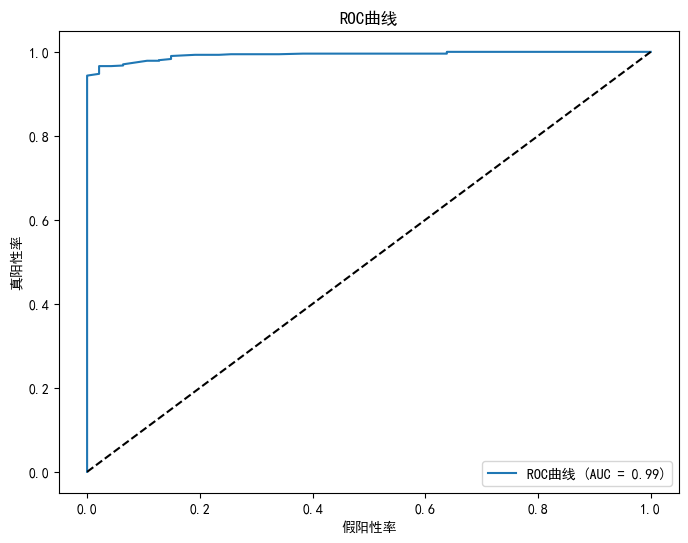

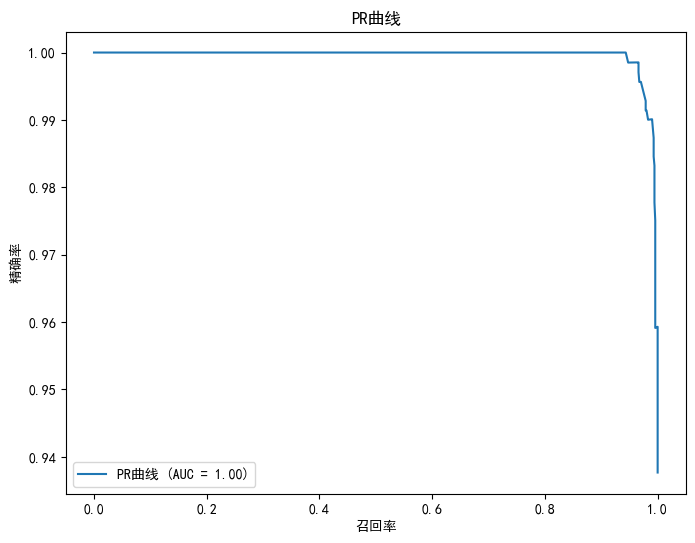

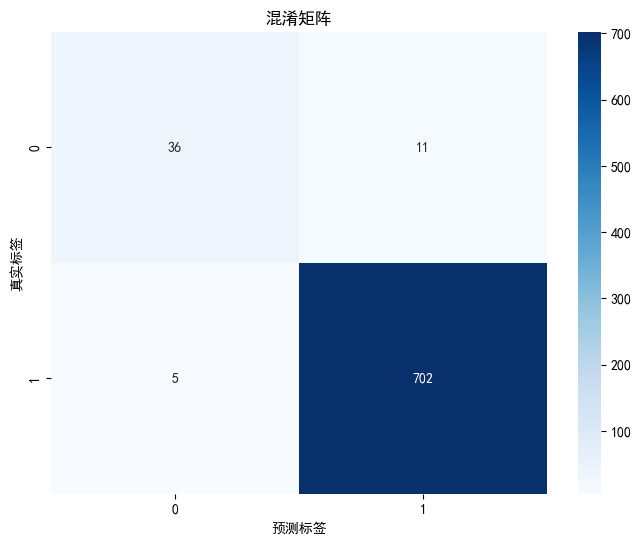

In [370]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("RF", rf_model)
])
pipe_rf.fit(X_train, y_train)

print_model_scores(pipe_rf, X_test, y_test)
plot_roc_curve(y_test, pipe_rf.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_rf.predict_proba(X_test)[:, 1])
y_pred_rf = pipe_rf.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf)

#### 逻辑回归

模型得分: 0.9456233421750663
召回率: 0.9900990099009901
AUC评分: 0.8375214421138162


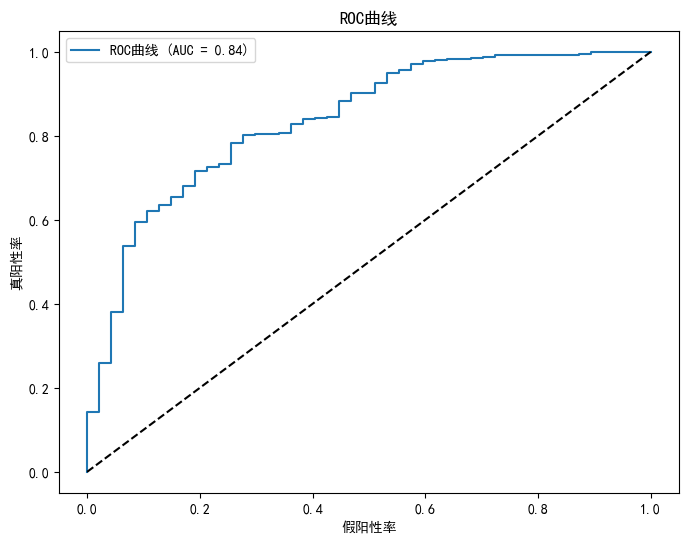

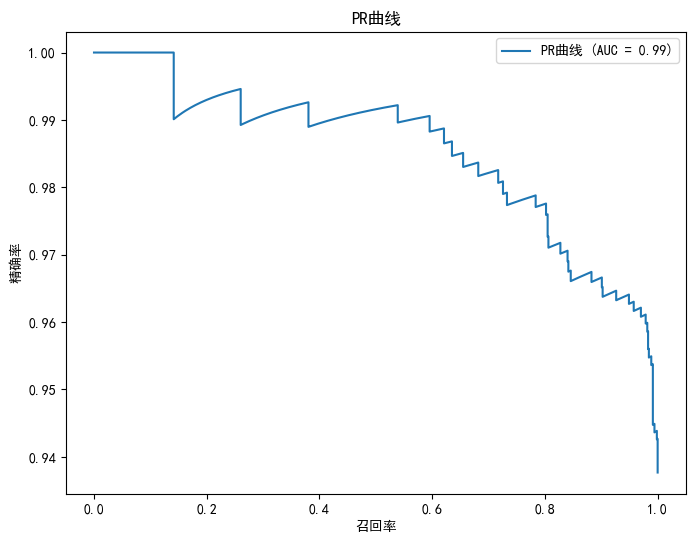

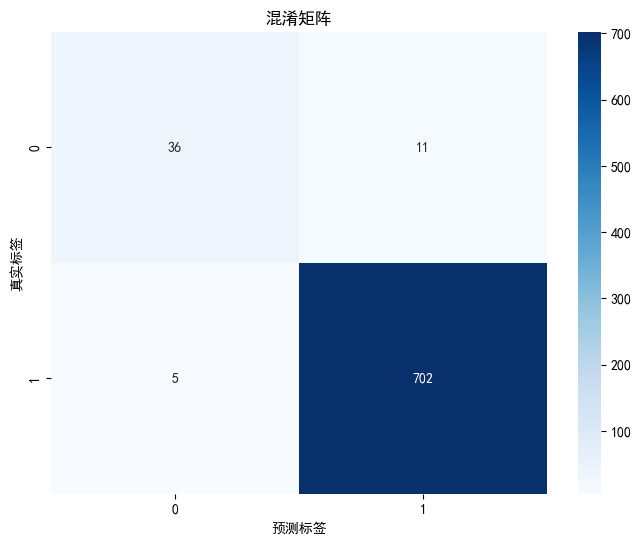

In [372]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(random_state=42)
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("LR", lr_model)
])
pipe_lr.fit(X_train, y_train)

print_model_scores(pipe_lr, X_test, y_test)
plot_roc_curve(y_test, pipe_lr.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_lr.predict_proba(X_test)[:, 1])
y_pred_rf = pipe_rf.predict(X_test)
plot_confusion_matrix(y_test, y_pred_rf)

#### GBDT

模型得分: 0.9774535809018567
召回率: 0.9787835926449788
AUC评分: 0.9944325739564838


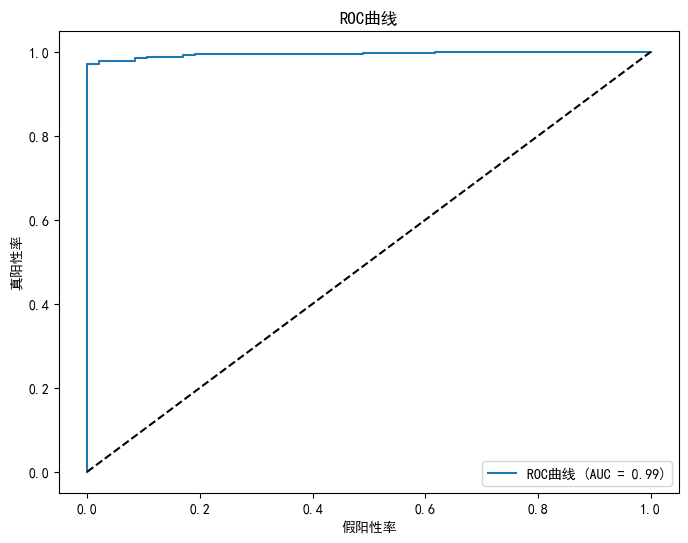

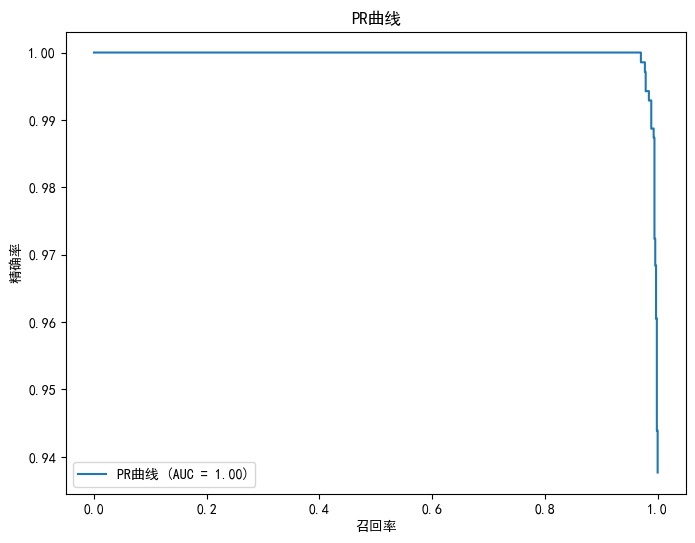

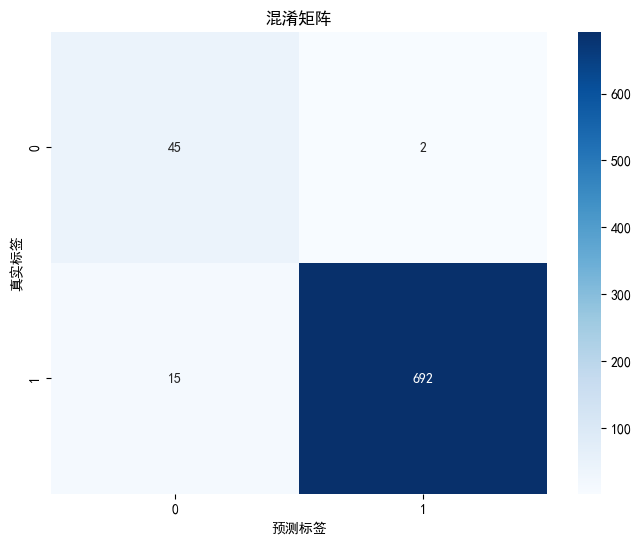

In [373]:
from sklearn.ensemble import GradientBoostingClassifier

gbdt_model = GradientBoostingClassifier(random_state=42)
pipe_gbdt = Pipeline([
    ("scaler", StandardScaler()),
    ("GBDT", gbdt_model)
])
pipe_gbdt.fit(X_train, y_train)

print_model_scores(pipe_gbdt, X_test, y_test)
plot_roc_curve(y_test, pipe_gbdt.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_gbdt.predict_proba(X_test)[:, 1])
y_pred_gbdt = pipe_gbdt.predict(X_test)
plot_confusion_matrix(y_test, y_pred_gbdt)

#### CatBoost

模型得分: 0.9774535809018567
召回率: 0.983026874115983
AUC评分: 0.9946733275151224


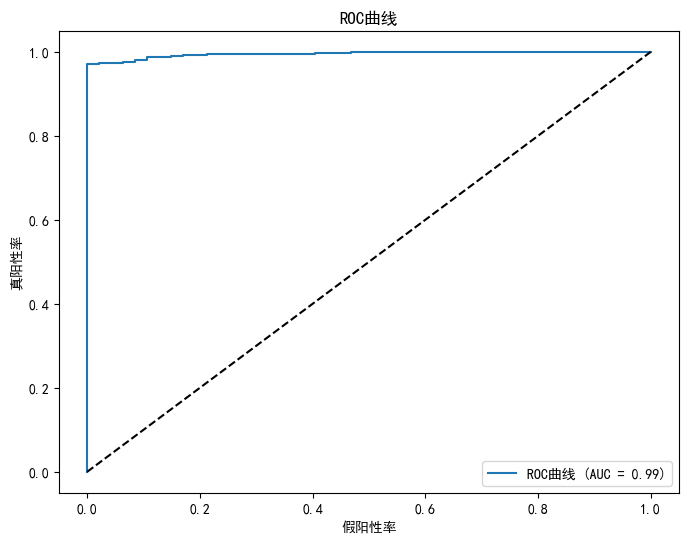

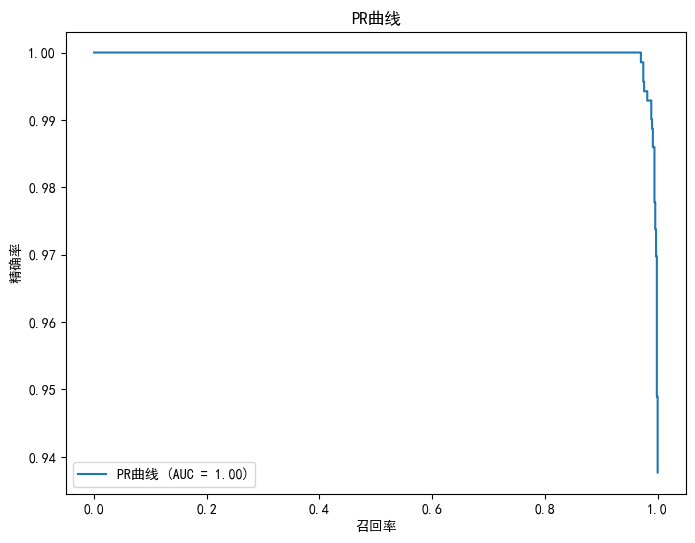

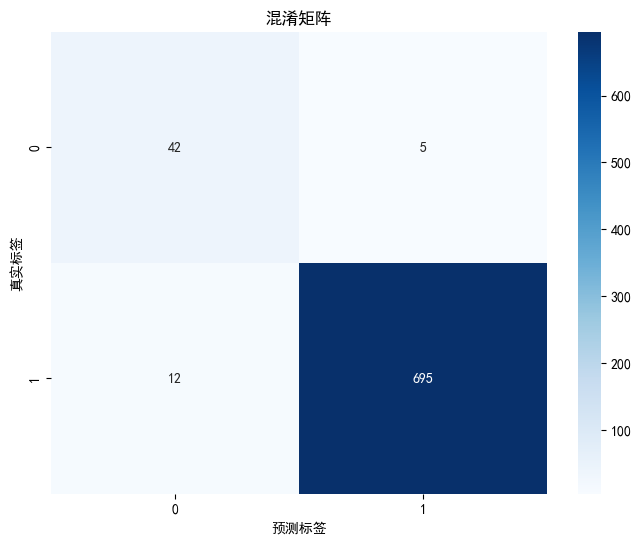

In [374]:
from catboost import CatBoostClassifier

catboost_model = CatBoostClassifier(random_state=42, verbose=False)
pipe_catboost = Pipeline([
    ("scaler", StandardScaler()),
    ("CatBoost", catboost_model)
])
pipe_catboost.fit(X_train, y_train)

print_model_scores(pipe_catboost, X_test, y_test)
plot_roc_curve(y_test, pipe_catboost.predict_proba(X_test)[:, 1])
plot_pr_curve(y_test, pipe_catboost.predict_proba(X_test)[:, 1])
y_pred_catboost = pipe_catboost.predict(X_test)
plot_confusion_matrix(y_test, y_pred_catboost)

### 模型对比

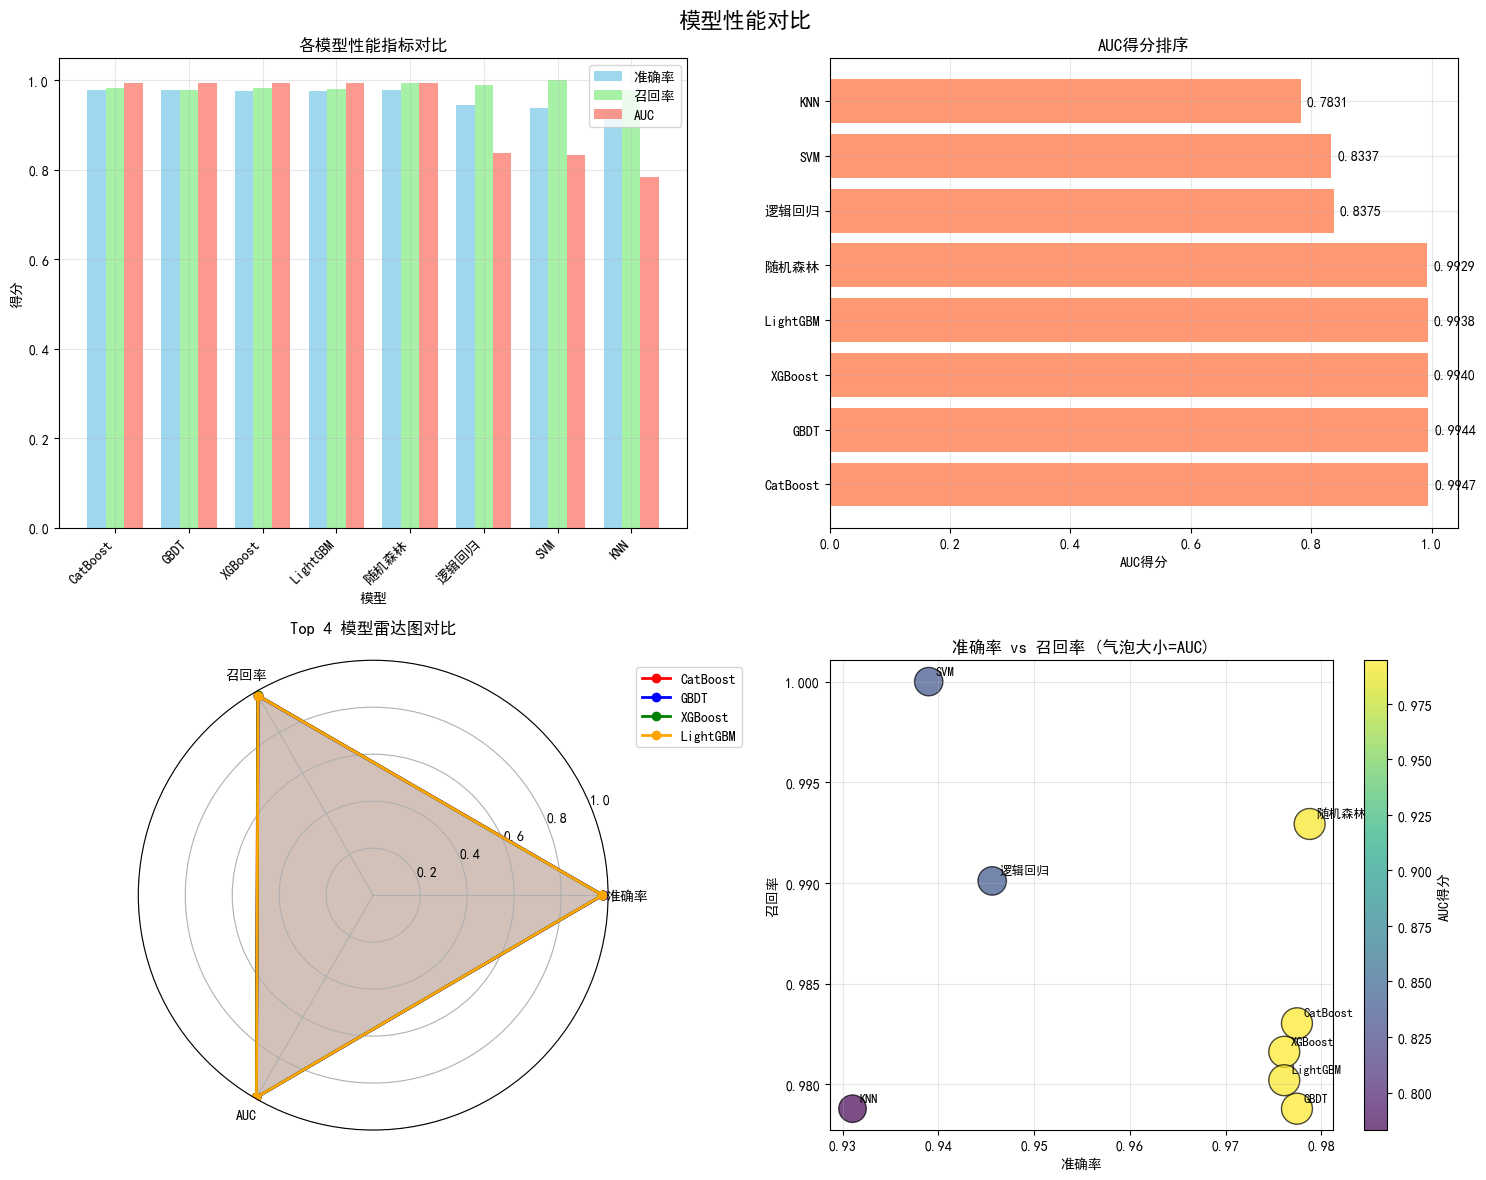

                    模型性能总结
      模型    准确率    召回率    AUC
CatBoost 0.9775 0.9830 0.9947
    GBDT 0.9775 0.9788 0.9944
 XGBoost 0.9761 0.9816 0.9940
LightGBM 0.9761 0.9802 0.9938
    随机森林 0.9788 0.9929 0.9929
    逻辑回归 0.9456 0.9901 0.8375
     SVM 0.9390 1.0000 0.8337
     KNN 0.9310 0.9788 0.7831


In [362]:
def compare_all_models(X_test, y_test):
    """
    对比所有模型的性能
    使用图表展示对比结果
    """
    models = {
        'XGBoost': pipe_xgb,
        'LightGBM': pipe_lgbm,
        'KNN': pipe_knn,
        'SVM': pipe_svm,
        '随机森林': pipe_rf,
        '逻辑回归': pipe_lr,
        'GBDT': pipe_gbdt,
        'CatBoost': pipe_catboost
    }
    
    results = []
    
    for name, model in models.items():
        # 计算各项指标
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        accuracy = model.score(X_test, y_test)
        recall = recall_score(y_test, y_pred)
        auc_score = roc_auc_score(y_test, y_pred_proba)
        
        results.append({
            '模型': name,
            '准确率': accuracy,
            '召回率': recall,
            'AUC': auc_score
        })
    
    # 转换为DataFrame并按AUC排序
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('AUC', ascending=False)
    
    # 创建图表展示
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('模型性能对比', fontsize=16, fontweight='bold')
    
    # 1. 柱状图 - 所有指标
    ax1 = axes[0, 0]
    x = np.arange(len(results_df))
    width = 0.25
    
    ax1.bar(x - width, results_df['准确率'], width, label='准确率', alpha=0.8, color='skyblue')
    ax1.bar(x, results_df['召回率'], width, label='召回率', alpha=0.8, color='lightgreen')
    ax1.bar(x + width, results_df['AUC'], width, label='AUC', alpha=0.8, color='salmon')
    
    ax1.set_xlabel('模型')
    ax1.set_ylabel('得分')
    ax1.set_title('各模型性能指标对比')
    ax1.set_xticks(x)
    ax1.set_xticklabels(results_df['模型'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(0, 1.05)
    
    # 2. AUC排序柱状图
    ax2 = axes[0, 1]
    bars = ax2.barh(results_df['模型'], results_df['AUC'], color='coral', alpha=0.8)
    ax2.set_xlabel('AUC得分')
    ax2.set_title('AUC得分排序')
    ax2.grid(True, alpha=0.3)
    
    # 在柱状图上添加数值
    for i, bar in enumerate(bars):
        width = bar.get_width()
        ax2.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{width:.4f}', ha='left', va='center', fontweight='bold')
    
    # 3. 雷达图
    ax3 = axes[1, 0]
    ax3.remove()  # 移除原有的子图
    ax3 = fig.add_subplot(2, 2, 3, projection='polar')
    
    # 选择前4个模型进行雷达图对比
    top4_models = results_df.head(4)
    categories = ['准确率', '召回率', 'AUC']
    angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
    angles += angles[:1]  # 闭合图形
    
    colors = ['red', 'blue', 'green', 'orange']
    for i, (idx, row) in enumerate(top4_models.iterrows()):
        values = [row['准确率'], row['召回率'], row['AUC']]
        values += values[:1]  # 闭合图形
        ax3.plot(angles, values, 'o-', linewidth=2, label=row['模型'], color=colors[i])
        ax3.fill(angles, values, alpha=0.1, color=colors[i])
    
    ax3.set_xticks(angles[:-1])
    ax3.set_xticklabels(categories)
    ax3.set_ylim(0, 1)
    ax3.set_title('Top 4 模型雷达图对比', pad=20)
    ax3.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))
    ax3.grid(True)
    
    # 4. 性能分布散点图
    ax4 = axes[1, 1]
    scatter = ax4.scatter(results_df['准确率'], results_df['召回率'], 
                         s=results_df['AUC']*500, alpha=0.7, c=results_df['AUC'], 
                         cmap='viridis', edgecolors='black')
    
    # 添加模型名称标注
    for i, row in results_df.iterrows():
        ax4.annotate(row['模型'], (row['准确率'], row['召回率']), 
                    xytext=(5, 5), textcoords='offset points', fontsize=9)
    
    ax4.set_xlabel('准确率')
    ax4.set_ylabel('召回率')
    ax4.set_title('准确率 vs 召回率 (气泡大小=AUC)')
    ax4.grid(True, alpha=0.3)
    
    # 添加颜色条
    cbar = plt.colorbar(scatter, ax=ax4)
    cbar.set_label('AUC得分')
    
    plt.tight_layout()
    plt.show()
    
    # 输出简洁的表格总结
    print("=" * 60)
    print("                    模型性能总结")
    print("=" * 60)
    summary_df = results_df.copy()
    summary_df['准确率'] = summary_df['准确率'].apply(lambda x: f"{x:.4f}")
    summary_df['召回率'] = summary_df['召回率'].apply(lambda x: f"{x:.4f}")
    summary_df['AUC'] = summary_df['AUC'].apply(lambda x: f"{x:.4f}")
    print(summary_df.to_string(index=False))
    print("=" * 60)
    
    return results_df

# 执行对比
model_comparison = compare_all_models(X_test, y_test)

### 超参优化

In [363]:
# # 网格搜索&交叉验证
# from sklearn.model_selection import GridSearchCV

# params = {
#     'CatBoost__iterations': [100, 200, 300],
#     'CatBoost__learning_rate': [0.05, 0.1, 0.2],
#     'CatBoost__depth': [4, 6, 8],
#     'CatBoost__l2_leaf_reg': [1, 3, 5]
# }

# grid_search_cat = GridSearchCV(pipe_catboost, params, cv=5, scoring='roc_auc', verbose=1)
# grid_search_cat.fit(X_train, y_train)
# print_model_scores(grid_search_cat, X_test, y_test)

In [364]:
# 更快更高效的超参优化方法
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, recall_score
from catboost import CatBoostClassifier
import optuna
import time
import warnings
warnings.filterwarnings("ignore")

# 设置optuna日志级别，减少输出
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Optuna目标函数：优化CatBoost关键参数
    只优化最重要的几个参数以提高效率
    """
    # 优化关键参数
    params = {
        'iterations': trial.suggest_int('iterations', 100, 300),  # 减少范围以提高速度
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.2),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 5),
        'random_state': 42,
        'verbose': False
    }
    
    # 创建模型
    model = CatBoostClassifier(**params)
    
    # 创建Pipeline
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("catboost", model)
    ])
    
    # 使用3折交叉验证评估AUC（减少折数以提高速度）
    scores = cross_val_score(pipe, X_train, y_train, cv=3, scoring='roc_auc')
    
    return scores.mean()

print("🚀 开始CatBoost超参数优化")
print("=" * 50)
print("📊 优化目标: 最大化AUC得分")
print("⚡ 优化算法: TPE (Tree-structured Parzen Estimator)")
print("🎯 试验次数: 20次 (高效模式)")
print("=" * 50)

# 创建study并设置优化方向
study = optuna.create_study(direction='maximize', 
                           sampler=optuna.samplers.TPESampler(seed=42))

# 记录开始时间
start_time = time.time()

# 执行优化（减少试验次数以控制时间）
study.optimize(objective, n_trials=20, show_progress_bar=True)

# 记录结束时间
end_time = time.time()

print(f"\n✅ 优化完成！耗时: {end_time - start_time:.1f}秒")
print("=" * 50)
print("🏆 最佳参数:")
for key, value in study.best_params.items():
    if isinstance(value, float):
        print(f"   {key}: {value:.4f}")
    else:
        print(f"   {key}: {value}")
print(f"\n🎯 最佳AUC得分: {study.best_value:.4f}")

# 使用最佳参数训练最终模型
print("\n" + "=" * 50)
print("🔧 使用最佳参数训练模型...")

best_catboost = CatBoostClassifier(**study.best_params)
best_pipe_catboost = Pipeline([
    ("scaler", StandardScaler()),
    ("catboost", best_catboost)
])

best_pipe_catboost.fit(X_train, y_train)

print("✅ 训练完成！")
print("\n" + "=" * 50)
print("📈 优化后模型在测试集上的表现:")

# 简化的评估函数
y_pred = best_pipe_catboost.predict(X_test)
y_pred_proba = best_pipe_catboost.predict_proba(X_test)[:, 1]
accuracy = best_pipe_catboost.score(X_test, y_test)
recall = recall_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_pred_proba)

print(f"   准确率: {accuracy:.4f}")
print(f"   召回率: {recall:.4f}")
print(f"   AUC评分: {auc_score:.4f}")

# 对比优化前后的性能
print("\n" + "=" * 50)
print("📊 优化前后对比:")
original_auc = roc_auc_score(y_test, pipe_catboost.predict_proba(X_test)[:, 1])
print(f"   优化前AUC: {original_auc:.4f}")
print(f"   优化后AUC: {auc_score:.4f}")
improvement = auc_score - original_auc
if improvement > 0:
    print(f"   🎉 性能提升: +{improvement:.4f}")
else:
    print(f"   📝 性能变化: {improvement:.4f}")
print("=" * 50)

🚀 开始CatBoost超参数优化
📊 优化目标: 最大化AUC得分
⚡ 优化算法: TPE (Tree-structured Parzen Estimator)
🎯 试验次数: 20次 (高效模式)


  0%|          | 0/20 [00:00<?, ?it/s]


✅ 优化完成！耗时: 34.3秒
🏆 最佳参数:
   iterations: 174
   learning_rate: 0.1063
   depth: 7
   l2_leaf_reg: 2.6947

🎯 最佳AUC得分: 0.9905

🔧 使用最佳参数训练模型...
0:	learn: 0.5733541	total: 3.17ms	remaining: 549ms
1:	learn: 0.4179050	total: 6.56ms	remaining: 564ms
2:	learn: 0.3633616	total: 9.92ms	remaining: 565ms
3:	learn: 0.2483945	total: 12.7ms	remaining: 540ms
4:	learn: 0.1846563	total: 15.6ms	remaining: 527ms
5:	learn: 0.1411485	total: 18.8ms	remaining: 525ms
6:	learn: 0.1179456	total: 22.6ms	remaining: 539ms
7:	learn: 0.0995289	total: 26.4ms	remaining: 549ms
8:	learn: 0.0882708	total: 29.9ms	remaining: 548ms
9:	learn: 0.0793257	total: 33.3ms	remaining: 547ms
10:	learn: 0.0734136	total: 36.9ms	remaining: 547ms
11:	learn: 0.0690914	total: 41.4ms	remaining: 559ms
12:	learn: 0.0666549	total: 45.3ms	remaining: 561ms
13:	learn: 0.0627322	total: 49.1ms	remaining: 561ms
14:	learn: 0.0595386	total: 53ms	remaining: 562ms
15:	learn: 0.0589574	total: 58.8ms	remaining: 581ms
16:	learn: 0.0571960	total: 62.7ms	rema

### 模型融合

In [365]:
# 模型融合：使用表现最好的几个模型进行集成
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

print("🔥 开始模型融合")
print("=" * 50)

# 1. 选择表现最好的几个基础模型
base_models = [
    ('catboost', pipe_catboost),
    ('lightgbm', pipe_lgbm), 
    ('gbdt', pipe_gbdt),
    ('xgboost', pipe_xgb)
]

print("📊 基础模型:")
for name, model in base_models:
    print(f"   - {name}")

# 2. 软投票集成（使用预测概率）
print("\n🗳️  方法1: 软投票集成")
voting_clf = VotingClassifier(
    estimators=base_models,
    voting='soft'  # 使用预测概率进行投票
)

voting_clf.fit(X_train, y_train)
print("✅ 训练完成")

print("📈 软投票集成结果:")
print_model_scores(voting_clf, X_test, y_test)

# 3. 堆叠集成（使用逻辑回归作为元学习器）
print("\n" + "=" * 50)
print("🏗️  方法2: 堆叠集成")
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(),  # 元学习器
    cv=3  # 3折交叉验证生成元特征
)

stacking_clf.fit(X_train, y_train)
print("✅ 训练完成")

print("📈 堆叠集成结果:")
print_model_scores(stacking_clf, X_test, y_test)

# 4. 性能对比
print("\n" + "=" * 50)
print("📊 融合效果对比")
print("=" * 50)

models_comparison = {
    'CatBoost(单模型)': pipe_catboost,
    'LightGBM(单模型)': pipe_lgbm,
    '软投票集成': voting_clf,
    '堆叠集成': stacking_clf
}

results = []
for name, model in models_comparison.items():
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    accuracy = model.score(X_test, y_test)
    results.append({
        '模型': name,
        '准确率': f"{accuracy:.4f}",
        'AUC': f"{auc_score:.4f}"
    })

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('AUC', key=lambda x: x.astype(float), ascending=False)

print(results_df.to_string(index=False))

# 5. 找出最佳模型
best_model_name = results_df.iloc[0]['模型']
best_auc = results_df.iloc[0]['AUC']

print("\n" + "=" * 50)
print(f"🏆 最佳模型: {best_model_name}")
print(f"🎯 最佳AUC: {best_auc}")
print("=" * 50)

🔥 开始模型融合
📊 基础模型:
   - catboost
   - lightgbm
   - gbdt
   - xgboost

🗳️  方法1: 软投票集成
✅ 训练完成
📈 软投票集成结果:
模型得分: 0.9774535809018567
召回率: 0.9816124469589816
AUC评分: 0.994733515904782

🏗️  方法2: 堆叠集成
✅ 训练完成
📈 堆叠集成结果:
模型得分: 0.9787798408488063
召回率: 0.9858557284299858
AUC评分: 0.9946432333202925

📊 融合效果对比
           模型    准确率    AUC
CatBoost(单模型) 0.9775 0.9947
        软投票集成 0.9775 0.9947
         堆叠集成 0.9788 0.9946
LightGBM(单模型) 0.9761 0.9938

🏆 最佳模型: CatBoost(单模型)
🎯 最佳AUC: 0.9947
